In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pyreadr import read_r
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
import json
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300


BUNDLE_DIR = Path.cwd().resolve()
ROOT_DIR = BUNDLE_DIR.parents[0]
RESULTS_DIR = BUNDLE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ─── Experiment variant ───────────────────────────────────────────────────
# Toggle EXCLUDE_DEAD_CELLS and CELL_TYPE_MERGE to switch between experiments.
EXCLUDE_DEAD_CELLS = True   # ← toggle: exclude programmed_death terminal cells
CELL_TYPE_MERGE = "D"       # ← toggle: None (original) | "A" (Schema A merge)
# Schema A: merges small classes per expression_embedding/cell_type_merge.md
#   Neuron | Muscle | Programmed death | Skin (hyp+tail+epi) |
#   Glia+excretory (sheath+socket+exc) | Pharynx+rectal (marg+valve+rect) |
#   Mesoderm+repro | Intestine | (drop: other)

if CELL_TYPE_MERGE == "A":
    _base = "elegans_protein_schemaA"
elif CELL_TYPE_MERGE is not None:
    _base = f"elegans_protein_schema{CELL_TYPE_MERGE}"
else:
    _base = "elegans_protein"

EXPERIMENT_NAME = (
    f"{_base}_no_dead_embedding" if EXCLUDE_DEAD_CELLS
    else f"{_base}_embedding"
)
EXPERIMENT_DIR = RESULTS_DIR / EXPERIMENT_NAME
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = ROOT_DIR / "data"
PROTEIN_DATA_DIR = DATA_DIR / "protein" / "aggregated_all"
CELL_LINEAGE_PATH = DATA_DIR / "cell_lineage.json"
CELL_TYPE_PATH = DATA_DIR / "2023-06-29_entropy_cell_key_V2.csv"
S3_PATH = PROTEIN_DATA_DIR / "s3.csv"
S3_ZSCORE_PATH = RESULTS_DIR / "s3_zscore.csv"  # shared intermediate, not per-experiment
PHASE2_CV_SUMMARY_PATH = EXPERIMENT_DIR / "phase2_cv_summary.csv"
FEATURE_EMBEDDINGS_PATH = EXPERIMENT_DIR / "embeddings_32d.csv"
FEATURE_SELECTED_PROTEINS_PATH = EXPERIMENT_DIR / "nn_selected_proteins_rev.tsv"
TISSUE_SPECIFIC_TF_PATH = PROTEIN_DATA_DIR / "tissue_specific_tf.tsv"

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
if str(BUNDLE_DIR) not in sys.path:
    sys.path.insert(0, str(BUNDLE_DIR))

def map_names(did):
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did


In [2]:
with CELL_LINEAGE_PATH.open('r', encoding='utf-8') as f:
    lineage_data = json.load(f)
terminal_nodes = []
intermediate_nodes = []
descendant_list_dict = defaultdict(list)

def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    if len(children) == 0:
        terminal_nodes.append(lookup_name)
        for ancestor in ancestors:
            descendant_list_dict[ancestor].append(lookup_name)
    else:
        intermediate_nodes.append(lookup_name)
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)
print(len(intermediate_nodes), len(terminal_nodes))

1091 1092


In [3]:
cell_type_df = pd.read_csv(CELL_TYPE_PATH)
cell_type_dict = {}
for node in terminal_nodes:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == node]
    if len(cur_cell_type_df) == 0:
        print(f"Warning: No cell type found for {node}")
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()].unique()
    if len(cur_lineage_types) == 0:
        cell_type_dict[node] = "programmed_death"
        continue
    if len(cur_lineage_types) > 1:
        print(f"Warning: Multiple cell types found for {node}: {cur_lineage_types}")
    cur_type = cur_lineage_types[0]
    cell_type_dict[node] = cur_type

In [4]:
# ─── Cell type merge schema ────────────────────────────────────────────────
# When CELL_TYPE_MERGE is active, remap cell_type_dict to merged classes
# per expression_embedding/cell_type_merge.md. "other" cells are recorded
# for exclusion from supervised training.

_n_cells_total = len(cell_type_dict)
_original_other_nodes = [node for node, ct in cell_type_dict.items() if ct == "other"]
_n_other = len(_original_other_nodes)

if CELL_TYPE_MERGE is not None:
    print(f"CELL_TYPE_MERGE = '{CELL_TYPE_MERGE}'")
    print(f"Original cell types: {len(set(cell_type_dict.values()))}, "
          f"total cells: {_n_cells_total}")

    if CELL_TYPE_MERGE == "A":
        MERGE_MAP = {
            "neuron":      "Neuron",
            "muscle":      "Muscle",
            "programmed_death": "Programmed death",
            "hypoderm":    "Skin",
            "tail":        "Skin",
            "epithelium":  "Skin",
            "mesoderm":    "Skin",
            "repro":       "Skin",
            "sheath":      "Glia + excretory",
            "socket":      "Glia + excretory",
            "excretory":   "Glia + excretory",
            "coelomocyte": "Glia + excretory",
            "gland":       "Glia + excretory",
            "marginal":    "Pharynx + rectal",
            "valve":       "Pharynx + rectal",
            "rectal":      "Pharynx + rectal",
            "intestine":   "Pharynx + rectal",
            # "other" intentionally omitted → excluded from training
        }
        _DEATH_LABEL_HINT = "death"  # keyword to find death class in merged set
    elif CELL_TYPE_MERGE == "D":
        # Schema D — biologist's feedback (see cell_type_merge.md)
        #   neuron | muscle | reproduction | epithelium (hyp+epi) |
        #   glial (sheath+socket) | alimentary (int+valve+marg+gland+rect) |
        #   coelomocyte | excretory | mesoderm | other |
        #   programmed_death (+ tail)
        MERGE_MAP = {
            "neuron":      "neuron",
            "muscle":      "muscle",
            "repro":       "reproduction",
            "hypoderm":    "epithelium",
            "epithelium":  "epithelium",
            "sheath":      "glial",
            "socket":      "glial",
            "coelomocyte": "coelomocyte",
            "excretory":   "excretory",
            "mesoderm":    "mesoderm",
            "other":       "other",
            "intestine":   "alimentary",
            "valve":       "alimentary",
            "marginal":    "alimentary",
            "gland":       "alimentary",
            "rectal":      "alimentary",
            "tail":        "programmed_death",  # "tail spike → die anyways"
            "programmed_death": "programmed_death",
            # "blast" omitted → excluded from training
        }
        _DEATH_LABEL_HINT = "programmed_death"

        n_remapped = 0
        for node in cell_type_dict:
            if cell_type_dict[node] in MERGE_MAP:
                cell_type_dict[node] = MERGE_MAP[cell_type_dict[node]]
                n_remapped += 1

        merged_types = sorted(set(v for v in cell_type_dict.values() if v is not None and v != "other"))
        print(f"Schema A applied: {n_remapped} terminal cells remapped")
        print(f"Merged classes ({len(merged_types)}): {merged_types}")
        print(f"'other' cells excluded from training: {_n_other}")
else:
    print(f"CELL_TYPE_MERGE = None (original {len(set(cell_type_dict.values()))} cell types)")
    _original_other_nodes = []

# Track the death-related class name for downstream cells
# (Schema A renames it to "Programmed death")
_DEATH_LABEL = None
for ct in set(cell_type_dict.values()):
    if ct is not None and "death" in ct.lower():
        _DEATH_LABEL = ct
        break
if _DEATH_LABEL is None:
    _DEATH_LABEL = "programmed_death"  # fallback


CELL_TYPE_MERGE = 'D'
Original cell types: 18, total cells: 1092
Schema A applied: 1092 terminal cells remapped
Merged classes (10): ['alimentary', 'coelomocyte', 'epithelium', 'excretory', 'glial', 'mesoderm', 'muscle', 'neuron', 'programmed_death', 'reproduction']
'other' cells excluded from training: 15


In [5]:
# one hot encoding of cell types, meaining each cell is assigned an one-hot vector corresponding to its type, this is used for the cell type prediction task
# rank the cell types by their frequency and assign an integer to each type
# programmed_death should be assigned as the last tpye since it's kind of special
cell_types = list(set(cell_type_dict.values()))
cell_types = [ct for ct in cell_types if ct != _DEATH_LABEL]
cell_types = sorted(cell_types, key=lambda x: sum([1 for v in cell_type_dict.values() if v == x]), reverse=True)
cell_types.append(_DEATH_LABEL)
cell_type_to_int = {ct: i for i, ct in enumerate(cell_types)}
cell_type_one_hot = {}
for node, ct in cell_type_dict.items():
    one_hot = np.zeros(len(cell_types))
    one_hot[cell_type_to_int[ct]] = 1
    cell_type_one_hot[node] = one_hot


In [6]:
# for internal node, the cell type is calculated as the sum of all its descendant terminal nodes'
# one-hot vectors and then normalized to get a distribution over cell types, this is used for the cell type prediction task
for node in intermediate_nodes:
    descendant_types = [cell_type_one_hot[desc] for desc in descendant_list_dict[node]]
    if len(descendant_types) == 0:
        print(f"Warning: No descendant types found for {node}")
        cell_type_one_hot[node] = np.zeros(len(cell_types))
        continue
    summed_types = np.sum(descendant_types, axis=0)
    normalized_types = summed_types / np.sum(summed_types)
    cell_type_one_hot[node] = normalized_types

In [7]:
protein_exp = pd.read_csv(S3_PATH, index_col=0).T
protein_exp = protein_exp.fillna(0)

In [8]:
protein_exp.head()

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
AHR-1_SYS571,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALR-1_RW10757,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALR-1_SYS139,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALY-1_SYS619,0.0,0.0,0.0,33.29,153.49,146.94,182.34,109.03,60.47,77.66,...,65.56,66.3,85.99,42.42,41.02,0.0,0.0,0.0,0.0,0.0


In [9]:
# z-score normalization for each gene across all cells
# genes are rows and cells are columns, so we need to normalize across columns for each row
# but first, get rid of the genes that all all zero across all cells, since they are not informative at all and will cause problems for z-score normalization
protein_exp = protein_exp[~(protein_exp == 0).all(axis=1)]
protein_exp_zscore = protein_exp.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
protein_exp_zscore.head()

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,...,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020
ALR-1_RW10757,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,...,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592
ALR-1_SYS139,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,...,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730
ALY-1_SYS619,-1.574885,-1.574885,-1.574885,-0.827994,1.868800,1.721845,2.516075,0.871300,-0.218186,0.167487,...,-0.103988,-0.087385,0.354377,-0.623154,-0.654564,-1.574885,-1.574885,-1.574885,-1.574885,-1.574885
ALY-2_SYS721,-1.899774,0.540951,0.282820,-0.438411,1.413989,-0.005436,0.402139,-0.413011,0.229067,-0.008389,...,0.939666,1.108012,1.089110,0.777817,-0.046784,0.071944,0.232612,0.918992,5.526953,5.323166


In [10]:
# Save the z-scored protein matrix for downstream bundle notebooks.
protein_exp_zscore.to_csv(S3_ZSCORE_PATH)
print(f"Saved z-scored protein matrix to {S3_ZSCORE_PATH}")

Saved z-scored protein matrix to /home/bingran/code/embryogenesis/expression_embedding/results/s3_zscore.csv


In [11]:
# set up training data
# X will be the value of protein_exp_zscore
# y will be the cell type one-hot vector
X = protein_exp_zscore.values.T
y = np.array([cell_type_one_hot[map_names(node)] for node in protein_exp_zscore.columns])
print(X.shape, y.shape)

(1204, 210) (1204, 11)


In [12]:
# for each sample, there is also consideration given to the difference between hard labels and soft mixed labels
# it should be the inverse of how many descendant terminal nodes it has, since the more descendant terminal nodes it has, the softer the label is, and the less weight it should have in the training process
sample_weights = np.array([1/len(descendant_list_dict[map_names(node)]) if len(descendant_list_dict[map_names(node)]) > 0 else 1 for node in protein_exp_zscore.columns])
print(sample_weights.shape)

(1204,)


Terminal (hard): 494  |  Intermediate (soft): 710


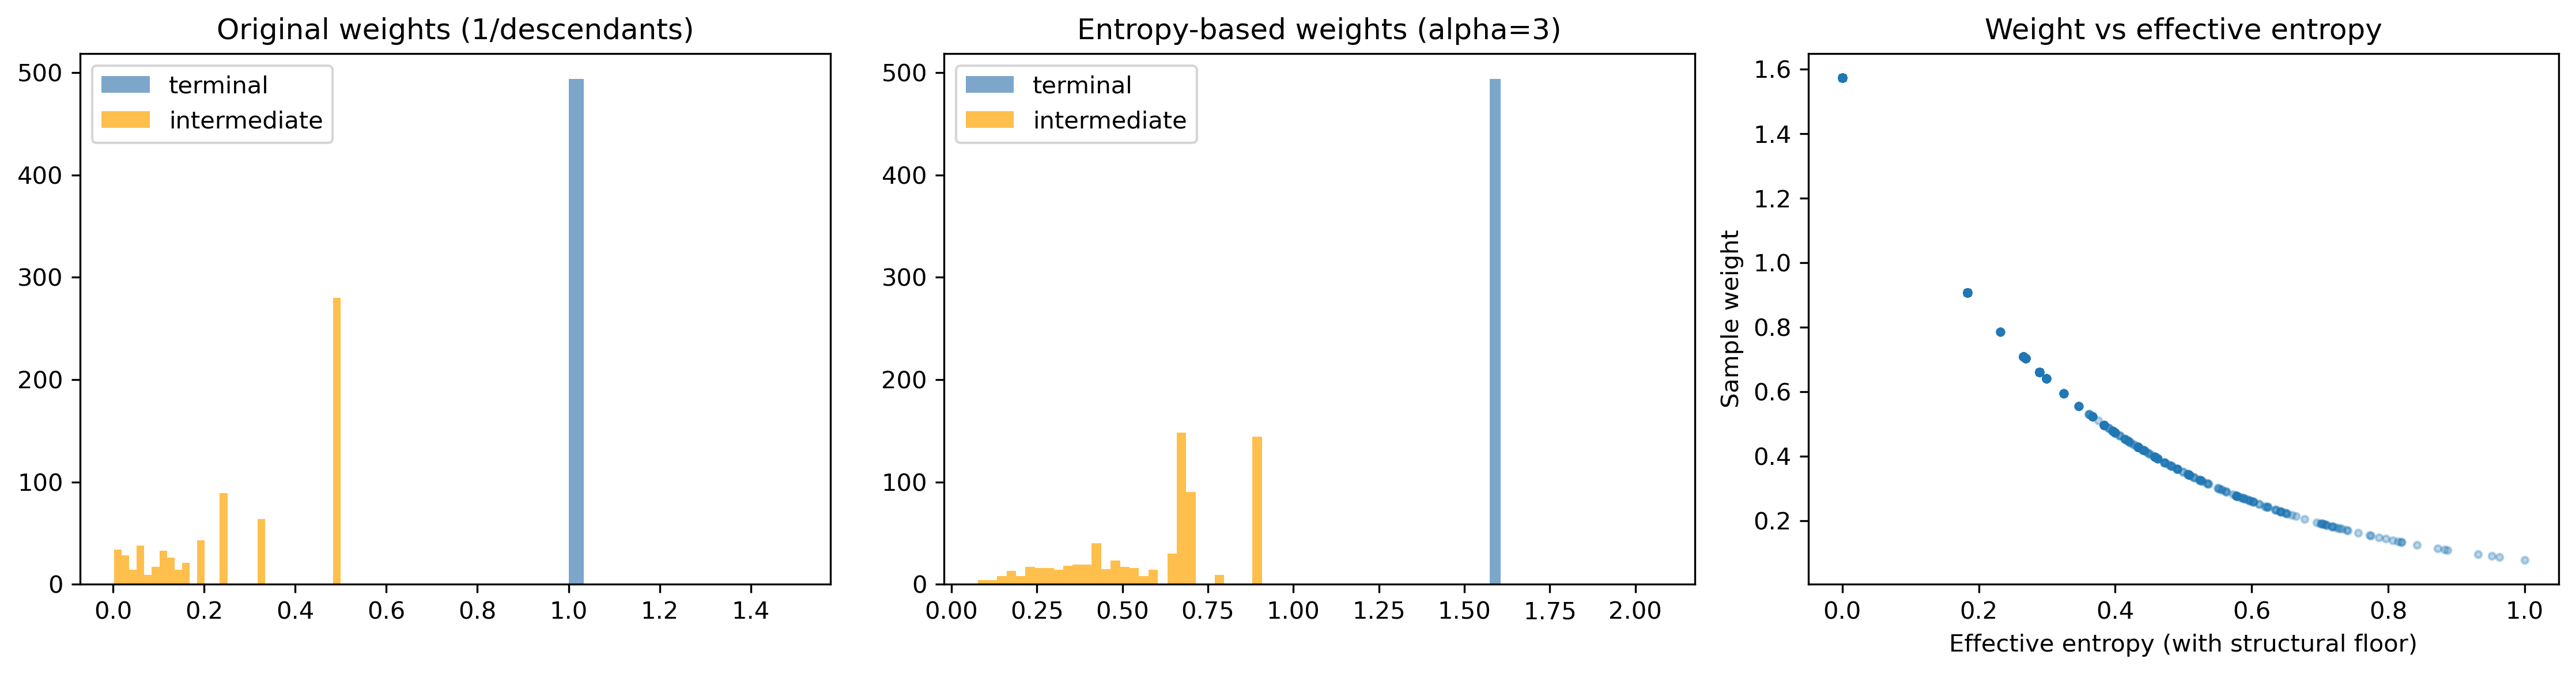

Hard nodes  – mean_w=1.574, max_w=1.574
Soft nodes  – mean_w=0.601, max_w=0.908


In [13]:
# === Improved Sample Weights: Entropy-Based ===
# 
# The original 1/num_descendants scheme is a proxy for label hardness, but
# entropy of the soft label directly measures uncertainty regardless of tree depth.
# Hard (terminal) nodes have one-hot labels → H=0 → weight≈1.
# Soft (intermediate) nodes have mixed labels → H>0 → weight<1.
#
# Fix: a progenitor whose descendants are all the same type also gets a one-hot
# soft label (H=0), but it should NOT receive the same weight as a true terminal.
# We add a structural floor: log(1+n_desc)/log(1+max_desc) ensures every
# intermediate node has a minimum effective entropy > 0.

def entropy_based_weights(y_soft, n_descendants, alpha=3.0):
    """
    alpha: sharpness. Higher alpha → harder labels get even more relative weight.
    n_descendants: array of descendant counts per sample (0 for terminals).
    Returns weights normalized so mean=1.
    """
    y_clipped = np.clip(y_soft, 1e-10, 1.0)
    entropies = -np.sum(y_clipped * np.log(y_clipped), axis=1)
    max_ent = np.log(y_soft.shape[1])
    norm_ent = entropies / max_ent          # 0=hard/one-hot, 1=uniform

    # Structural floor: 0 for terminals, >0 for intermediates
    max_desc = max(n_descendants.max(), 1)
    structural_floor = np.log1p(n_descendants) / np.log1p(max_desc)

    # Effective entropy = max(label entropy, structural floor)
    effective_ent = np.maximum(norm_ent, structural_floor)

    weights = np.exp(-alpha * effective_ent)
    return (weights / weights.mean()).astype(np.float32)

n_descendants = np.array([
    len(descendant_list_dict[map_names(node)])
    for node in protein_exp_zscore.columns
])
sample_weights_v2 = entropy_based_weights(y, n_descendants, alpha=3.0)

# Mask for terminal (hard-label) vs intermediate (soft-label) nodes
terminal_mask = np.array([
    len(descendant_list_dict[map_names(node)]) == 0
    for node in protein_exp_zscore.columns
])
print(f"Terminal (hard): {terminal_mask.sum()}  |  Intermediate (soft): {(~terminal_mask).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sample_weights[terminal_mask], bins=30, alpha=0.7, color='steelblue', label='terminal')
axes[0].hist(sample_weights[~terminal_mask], bins=30, alpha=0.7, color='orange', label='intermediate')
axes[0].set_title('Original weights (1/descendants)')
axes[0].legend()

axes[1].hist(sample_weights_v2[terminal_mask], bins=30, alpha=0.7, color='steelblue', label='terminal')
axes[1].hist(sample_weights_v2[~terminal_mask], bins=30, alpha=0.7, color='orange', label='intermediate')
axes[1].set_title('Entropy-based weights (alpha=3)')
axes[1].legend()

# use effective entropy (with structural floor) for the scatter plot
max_desc = max(n_descendants.max(), 1)
structural_floor = np.log1p(n_descendants) / np.log1p(max_desc)
norm_ent_all = -np.sum(np.clip(y, 1e-10,1) * np.log(np.clip(y, 1e-10,1)), axis=1) / np.log(y.shape[1])
effective_ent_all = np.maximum(norm_ent_all, structural_floor)
axes[2].scatter(effective_ent_all, sample_weights_v2, alpha=0.3, s=8)
axes[2].set_xlabel('Effective entropy (with structural floor)')
axes[2].set_ylabel('Sample weight')
axes[2].set_title('Weight vs effective entropy')

plt.tight_layout()
plt.show()

print(f"Hard nodes  – mean_w={sample_weights_v2[terminal_mask].mean():.3f}, max_w={sample_weights_v2[terminal_mask].max():.3f}")
print(f"Soft nodes  – mean_w={sample_weights_v2[~terminal_mask].mean():.3f}, max_w={sample_weights_v2[~terminal_mask].max():.3f}")

In [14]:
# ─── Control: exclude programmed death terminal cells from training ─────────
#
# When True, hard-labeled "programmed_death" terminal cells are excluded from
# training. Intermediate progenitor soft labels are unchanged (dead cell
# descendants still contribute to their mixture). The trained model can still
# be applied to dead cells at inference time.
# Identify programmed death terminal cells
dead_type_idx = cell_type_to_int.get(_DEATH_LABEL, -1)
dead_terminal_mask = np.array([
    terminal_mask[i] and y[i].argmax() == dead_type_idx
    for i in range(len(y))
])

# Training mask: exclude dead terminal cells and/or "other" cells
# (Schema A drops "other" from supervised training)
train_mask = np.ones(len(y), dtype=bool)
if EXCLUDE_DEAD_CELLS:
    train_mask &= ~dead_terminal_mask
if CELL_TYPE_MERGE is not None:
    # Identify terminal cells whose original type was "other"
    other_terminal_mask = np.array([
        terminal_mask[i] and map_names(node) in _original_other_nodes
        for i, node in enumerate(protein_exp_zscore.columns)
    ])
    train_mask &= ~other_terminal_mask
    n_other_excluded = other_terminal_mask.sum()
else:
    n_other_excluded = 0

# Filtered datasets for training
X_train = X[train_mask]
y_train = y[train_mask]
sample_weights_train = sample_weights_v2[train_mask]
terminal_mask_train = terminal_mask[train_mask]

n_dead_term = dead_terminal_mask.sum()
n_term = terminal_mask.sum()
print(f"EXCLUDE_DEAD_CELLS = {EXCLUDE_DEAD_CELLS}")
print(f"CELL_TYPE_MERGE    = {CELL_TYPE_MERGE}")
print(f"Dead terminal cells excluded: {n_dead_term} ({n_dead_term/n_term*100:.1f}% of {n_term} terminal)")
print(f"'other' cells excluded: {n_other_excluded}")
print(f"Training samples: {train_mask.sum()} / {len(y)}")
print(f"  Terminal (hard): {terminal_mask_train.sum()}")
print(f"  Intermediate   : {(~terminal_mask_train).sum()}")

EXCLUDE_DEAD_CELLS = True
CELL_TYPE_MERGE    = D
Dead terminal cells excluded: 76 (15.4% of 494 terminal)
'other' cells excluded: 9
Training samples: 1119 / 1204
  Terminal (hard): 409
  Intermediate   : 710


In [15]:
from feature_selection import (
    SparseGateClassifier,
    FocusedClassifier,
    soft_cross_entropy,
    train_epoch,
    eval_accuracy,
    eval_prediction_metrics,
    cross_validate_features,
    cross_validate_focused,
    train_one_pass,
    train_focused,
)

print("feature_selection module loaded.")
print("  Models   : SparseGateClassifier, FocusedClassifier")
print("  CV       : cross_validate_features, cross_validate_focused")
print("  Metrics  : eval_accuracy, eval_prediction_metrics")
print("  Training : train_one_pass, train_focused")

feature_selection module loaded.
  Models   : SparseGateClassifier, FocusedClassifier
  CV       : cross_validate_features, cross_validate_focused
  Metrics  : eval_accuracy, eval_prediction_metrics
  Training : train_one_pass, train_focused


In [16]:

# Training utilities (soft_cross_entropy, train_epoch, eval_accuracy,
# entropy_based_weights) are provided by feature_selection.py and imported
# in the cell above. Nothing to define here.


Device: cuda
CV verbose logging: True
[protein phase1] config 1/18 start {'l1_lambda': 0.002, 'hidden_dims': (128, 64), 'dropout': 0.2}


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[protein phase1] config 1/18 fold 1/5 train_acc=1.0000 val_acc=0.7927 val_loss=0.8258 selector_epochs=129


[protein phase1] config 1/18 fold 2/5 train_acc=1.0000 val_acc=0.7901 val_loss=0.7593 selector_epochs=273


[protein phase1] config 1/18 fold 3/5 train_acc=1.0000 val_acc=0.7416 val_loss=1.0145 selector_epochs=180


...

[protein phase1] config 18/18 fold 3/5 train_acc=0.9906 val_acc=0.7753 val_loss=0.9054 selector_epochs=251


[protein phase1] config 18/18 fold 4/5 train_acc=1.0000 val_acc=0.7750 val_loss=0.9607 selector_epochs=166


[protein phase1] config 18/18 fold 5/5 train_acc=0.9970 val_acc=0.9091 val_loss=0.5790 selector_epochs=266
[protein phase1] config 18/18 done mean_val_acc=0.8061 mean_train_acc=0.9957 mean_overfit_gap=0.1896 stability=0.5153 score=0.6708

Top Phase-1 configs by stability-aware score:


,l1_lambda,hidden_dims,dropout,mean_val_acc,mean_train_acc,mean_overfit_gap,mean_jaccard,mean_topk_frequency,consensus_ratio,selection_stability_score,score
0,0.002,"(128, 64)",0.3,0.8152,0.9988,0.1835,0.4129,0.7200,0.5333,0.5905,0.7070
1,0.004,"(128, 64)",0.3,0.8149,0.9982,0.1832,0.3985,0.7467,0.6000,0.5901,0.7067
2,0.002,"(128, 64, 32)",0.3,0.8171,0.9853,0.1681,0.3778,0.7333,0.4667,0.5730,0.7027
3,0.002,"(128, 64, 32)",0.2,0.8151,0.9969,0.1818,0.3771,0.7200,0.5333,0.5717,0.6996
4,0.004,"(128, 64, 32)",0.3,0.8222,0.9871,0.1649,0.3622,0.7067,0.5333,0.5556,0.6991
5,0.004,"(64, 32)",0.3,0.8010,0.9951,0.1941,0.3696,0.7067,0.4000,0.5592,0.6848
6,0.004,"(128, 64, 32)",0.2,0.8247,0.9969,0.1723,0.3073,0.6667,0.4000,0.5166,0.6842
7,0.002,"(64, 32)",0.3,0.7979,0.9951,0.1972,0.3649,0.6933,0.5333,0.5542,0.6807



Best selector config: {'l1_lambda': 0.002, 'hidden_dims': (128, 64), 'dropout': 0.3}


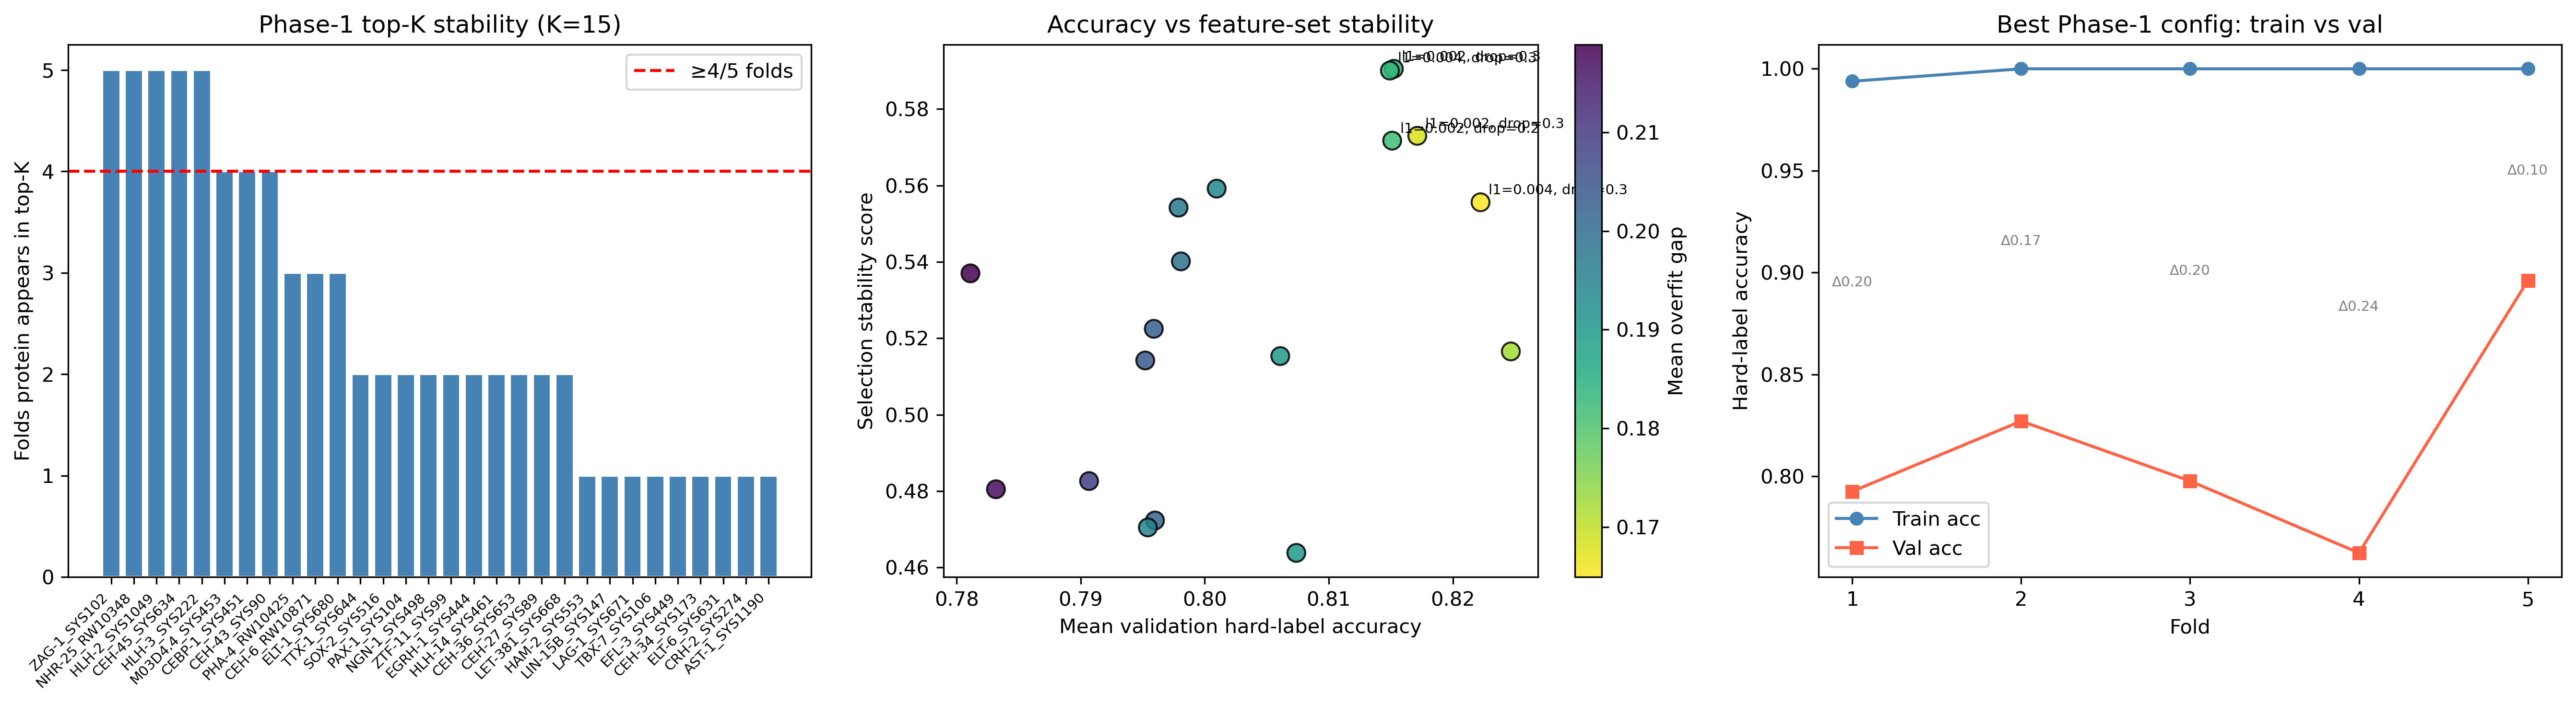


Best Phase-1 stability summary:
  Mean Jaccard              : 0.4129 ± 0.0804
  Mean top-K frequency      : 0.7200
  Consensus ratio           : 0.5333
  Mean Spearman             : 0.7611
  Stability-aware score     : 0.5905


In [17]:
import torch
import torch.nn.functional as F

# ─── Device & shared tensors ──────────────────────────────────────────────────
# include apple's mps as second priority after cuda
device = torch.device('mps') if torch.mps.is_available() else torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Device: {device}")

feature_names = np.array(protein_exp_zscore.index.tolist())
PHASE1_STABILITY_K = 15

X_t    = torch.FloatTensor(X)
y_t    = torch.FloatTensor(y)
w_t    = torch.FloatTensor(sample_weights_v2)
term_t = torch.BoolTensor(terminal_mask)

# ─── Cross-Validation: Phase 1 sparse-gate search with stability-aware ranking ─
PHASE1_PARAM_GRID = {
    'l1_lambda':   [0.002, 0.004, 0.008],
    'hidden_dims': [(128, 64), (128, 64, 32), (64, 32)],
    'dropout':     [0.2, 0.3],
}

PHASE1_SCORE_WEIGHTS = {
    'val_acc': 0.60,
    'selection_stability': 0.40,
    'overfit_gap': 0.10,
}

PHASE1_STABILITY_WEIGHTS = {
    'jaccard': 0.50,
    'topk_frequency': 0.35,
    'spearman': 0.15,
}

PHASE1_CV_EPOCHS = 300
CV_VERBOSE = True
PHASE1_CV_EARLY_STOPPING_PATIENCE = 25
PHASE2_SELECTOR_EARLY_STOPPING_PATIENCE = 20
PHASE2_CV_EARLY_STOPPING_PATIENCE = 25
FINAL_PHASE1_EARLY_STOPPING_PATIENCE = 30
FINAL_PHASE2_EARLY_STOPPING_PATIENCE = 30

print(f"CV verbose logging: {CV_VERBOSE}")

cv_results, best_selector_config = cross_validate_features(
    X_train, y_train, sample_weights_train, terminal_mask_train,
    param_grid = PHASE1_PARAM_GRID,
    n_splits   = 5,
    n_select   = PHASE1_STABILITY_K,
    n_epochs   = PHASE1_CV_EPOCHS,
    batch_size = 127,
    device     = str(device),
    score_weights = PHASE1_SCORE_WEIGHTS,
    stability_metric_weights = PHASE1_STABILITY_WEIGHTS,
    early_stopping_patience = PHASE1_CV_EARLY_STOPPING_PATIENCE,
    verbose = CV_VERBOSE,
    log_prefix = 'protein phase1',
 )

summary_rows = []
for r in cv_results:
    row = {
        **r['config'],
        **r['summary'],
        'score': round(r['score'], 5),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values('score', ascending=False)
best_result = cv_results[0]

display_cols = [
    'l1_lambda',
    'hidden_dims',
    'dropout',
    'mean_val_acc',
    'mean_train_acc',
    'mean_overfit_gap',
    'mean_jaccard',
    'mean_topk_frequency',
    'consensus_ratio',
    'selection_stability_score',
    'score',
]

print("\nTop Phase-1 configs by stability-aware score:")
display(summary_df[display_cols].head(8).round(4))
print(f"\nBest selector config: {best_selector_config}")

freq = best_result['stability']['feature_frequency']
top_freq_idx = np.argsort(freq)[::-1][:PHASE1_STABILITY_K * 2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(range(len(top_freq_idx)), freq[top_freq_idx], color='steelblue', edgecolor='white')
ax.set_xticks(range(len(top_freq_idx)))
ax.set_xticklabels([feature_names[i] for i in top_freq_idx], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Folds protein appears in top-K')
ax.set_title(f'Phase-1 top-K stability (K={PHASE1_STABILITY_K})')
ax.axhline(4, color='red', linestyle='--', label='≥4/5 folds')
ax.legend()

ax = axes[1]
ax.scatter(
    summary_df['mean_val_acc'],
    summary_df['selection_stability_score'],
    s=80,
    c=summary_df['mean_overfit_gap'],
    cmap='viridis_r',
    edgecolor='black',
    alpha=0.85,
 )
ax.set_xlabel('Mean validation hard-label accuracy')
ax.set_ylabel('Selection stability score')
ax.set_title('Accuracy vs feature-set stability')
for _, row in summary_df.head(5).iterrows():
    ax.annotate(
        f"l1={row['l1_lambda']}, drop={row['dropout']}",
        (row['mean_val_acc'], row['selection_stability_score']),
        fontsize=7,
        xytext=(4, 4),
        textcoords='offset points',
    )
plt.colorbar(ax.collections[0], ax=ax, label='Mean overfit gap')

ax = axes[2]
fold_train = [fr['train_acc'] for fr in best_result['fold_results']]
fold_val   = [fr['val_acc']   for fr in best_result['fold_results']]
folds_x    = list(range(1, len(fold_train) + 1))
ax.plot(folds_x, fold_train, 'o-', label='Train acc', color='steelblue')
ax.plot(folds_x, fold_val,   's-', label='Val acc',   color='tomato')
for i, (tr, va) in enumerate(zip(fold_train, fold_val)):
    ax.annotate(f'Δ{tr - va:.2f}', xy=(i + 1, (tr + va) / 2), ha='center', fontsize=7, color='gray')
ax.set_xlabel('Fold')
ax.set_ylabel('Hard-label accuracy')
ax.set_title('Best Phase-1 config: train vs val')
ax.set_xticks(folds_x)
ax.legend()

plt.tight_layout()
plt.show()

print("\nBest Phase-1 stability summary:")
print(f"  Mean Jaccard              : {best_result['summary']['mean_jaccard']:.4f} ± {best_result['summary']['std_jaccard']:.4f}")
print(f"  Mean top-K frequency      : {best_result['summary']['mean_topk_frequency']:.4f}")
print(f"  Consensus ratio           : {best_result['summary']['consensus_ratio']:.4f}")
print(f"  Mean Spearman             : {best_result['summary']['mean_spearman']:.4f}")
print(f"  Stability-aware score     : {best_result['summary']['selection_stability_score']:.4f}")

[protein phase2 selector] fold 1/5 start train=895 val=224


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[protein phase2 selector] fold 1/5 ready selector_epochs=142 top_gate=0.5091
[protein phase2 selector] fold 2/5 start train=895 val=224


[protein phase2 selector] fold 2/5 ready selector_epochs=98 top_gate=0.5286
[protein phase2 selector] fold 3/5 start train=895 val=224


[protein phase2 selector] fold 3/5 ready selector_epochs=89 top_gate=0.5244
[protein phase2 selector] fold 4/5 start train=895 val=224


...

[protein phase2] config 48/48 fold 3/5 train_acc=0.9812 val_acc=0.8315 expected_target_prob=0.7056 soft_ce=0.9046 selector_epochs=89 focused_epochs=180


[protein phase2] config 48/48 fold 4/5 train_acc=1.0000 val_acc=0.8500 expected_target_prob=0.6854 soft_ce=1.0221 selector_epochs=82 focused_epochs=142


[protein phase2] config 48/48 fold 5/5 train_acc=0.9970 val_acc=0.8052 expected_target_prob=0.6864 soft_ce=0.7621 selector_epochs=146 focused_epochs=203
[protein phase2] config 48/48 done mean_val_acc=0.8360 mean_expected_target_prob=0.6908 mean_soft_ce=0.8294 mean_overfit_gap=0.1585 stability=0.4926
[protein phase2] config final {'n_select': 10, 'hidden_dims': (32,), 'dropout': 0.1, 'dist_lambda': 0.0} normalized_param_count=0.0000 score=0.5769
[protein phase2] config final {'n_select': 10, 'hidden_dims': (32,), 'dropout': 0.1, 'dist_lambda': 0.1} normalized_param_count=0.0000 score=0.5771
[protein phase2] config final {'n_select': 10, 'hidden_dims': (32,), 'dropout': 0.2, 'dist_lambda': 0.0} normalized_param_count=0.0000 score=0.5846
[protein phase2] config final {'n_select': 10, 'hidden_dims': (32,), 'dropout': 0.2, 'dist_lambda': 0.1} normalized_param_count=0.0000 score=0.5837
[protein phase2] config final {'n_select': 10, 'hidden_dims': (64, 32), 'dropout': 0.1, 'dist_lambda': 0.0

,n_select,hidden_dims,dropout,dist_lambda,mean_val_acc,mean_expected_target_probability,mean_soft_cross_entropy,mean_overfit_gap,mean_jaccard,consensus_ratio,n_parameters,normalized_param_count,score
0,20,"(32,)",0.1,0.0,0.8325,0.6437,0.8152,0.1099,0.4177,0.6,1099,0.0269,0.6469
1,20,"(32,)",0.2,0.0,0.8301,0.6390,0.8282,0.1110,0.4177,0.6,1099,0.0269,0.6442
2,25,"(32,)",0.2,0.1,0.8210,0.6621,0.8037,0.1289,0.4466,0.6,1259,0.0403,0.6430
3,20,"(32,)",0.1,0.1,0.8253,0.6416,0.8164,0.1140,0.4177,0.6,1099,0.0269,0.6418
4,25,"(32,)",0.2,0.0,0.8164,0.6638,0.7894,0.1419,0.4466,0.6,1259,0.0403,0.6389
5,25,"(32,)",0.1,0.1,0.8164,0.6668,0.7930,0.1530,0.4466,0.6,1259,0.0403,0.6380
6,25,"(32,)",0.1,0.0,0.8138,0.6685,0.7870,0.1592,0.4466,0.6,1259,0.0403,0.6361
7,25,"(64, 32)",0.2,0.0,0.8456,0.6848,0.7586,0.1372,0.4466,0.6,4299,0.2957,0.6354
8,25,"(64, 32)",0.2,0.1,0.8427,0.6819,0.7736,0.1389,0.4466,0.6,4299,0.2957,0.6328
9,20,"(32,)",0.2,0.1,0.8122,0.6385,0.8245,0.1234,0.4177,0.6,1099,0.0269,0.6324



Best Phase-2 config: {'n_select': 20, 'hidden_dims': (32,), 'dropout': 0.1, 'dist_lambda': 0.0}


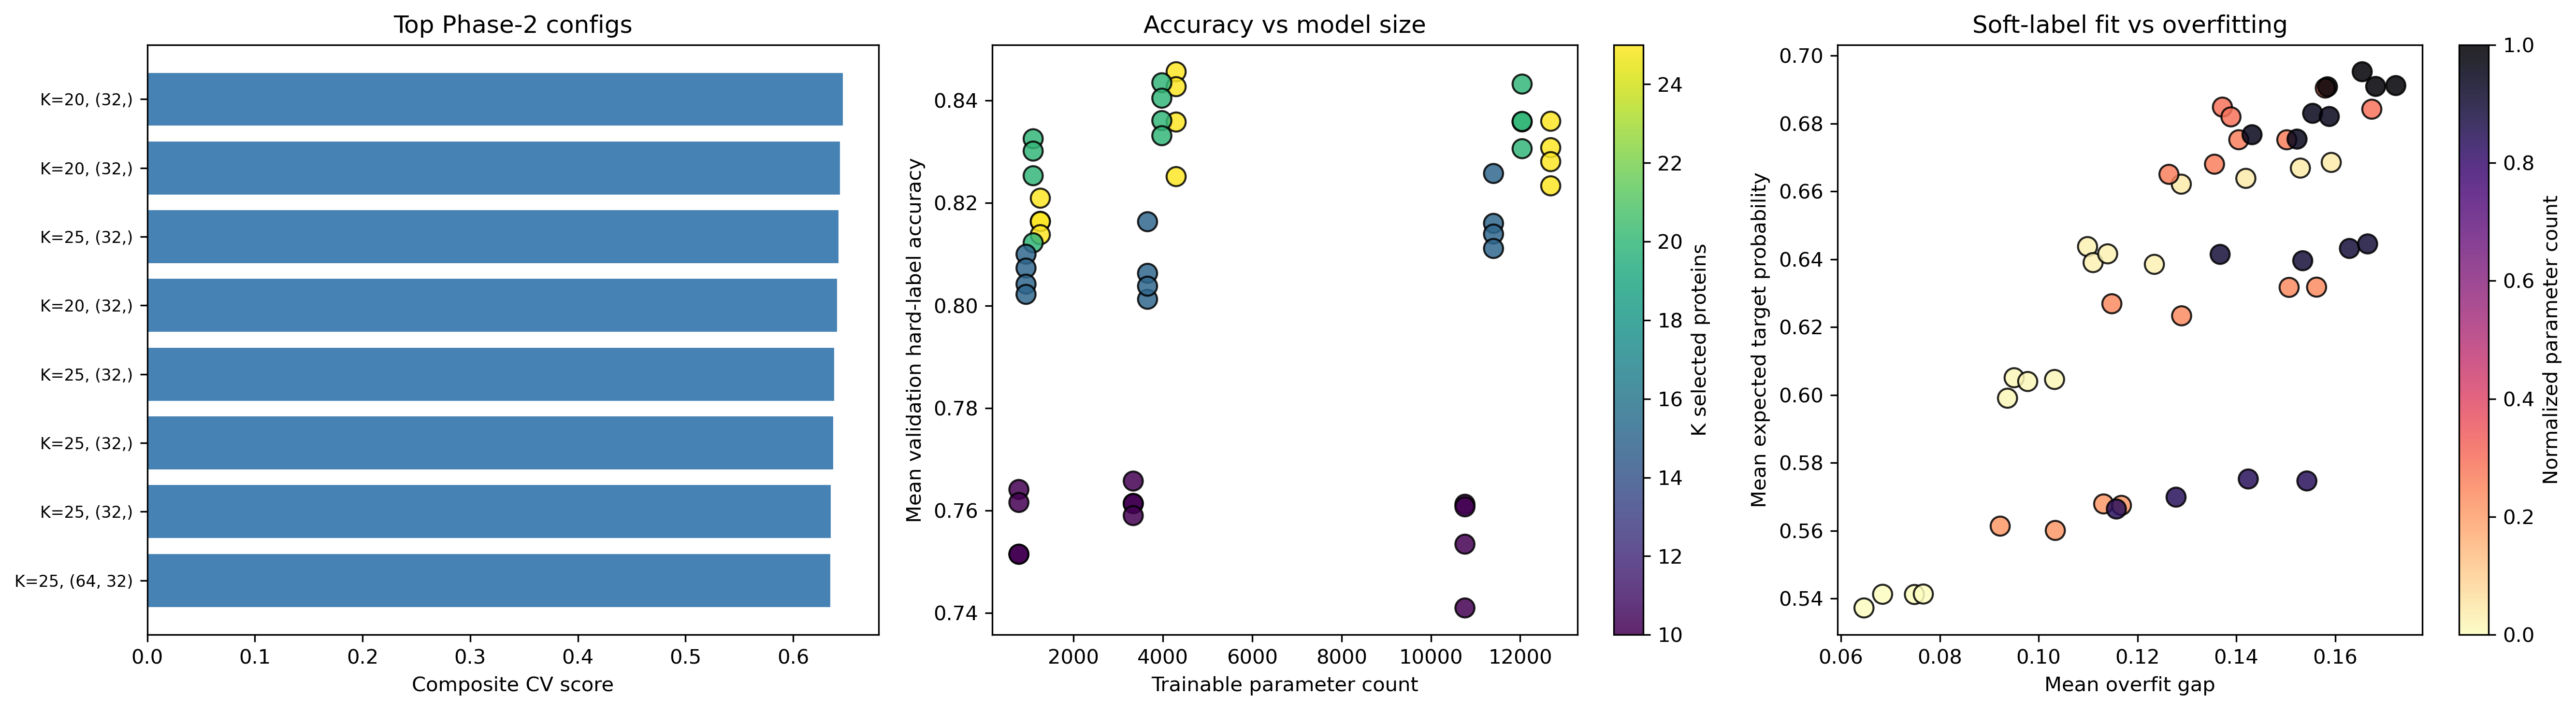


Best Phase-2 summary:
  Val hard-label acc        : 0.8325
  Soft target probability   : 0.6437
  Soft cross-entropy        : 0.8152
  Overfit gap               : 0.1099
  Top-K stability (Jaccard) : 0.4177
  Consensus ratio           : 0.6000
  Parameter count           : 1099


In [18]:
# ─── Cross-Validation: Phase 2 focused model + K search ──────────────────────
#

# We treat K (the number of selected proteins) as a tunable hyperparameter.
# Each CV fold re-runs Phase 1 feature selection on the training split only, so
# the chosen K and the focused model size are evaluated without feature leakage.

PHASE2_PARAM_GRID = {
    'n_select':    [10, 15, 20, 25],
    'hidden_dims': [(32,), (64, 32), (128, 64)],
    'dropout':     [0.1, 0.2],
    'dist_lambda': [0.0, 0.1],
}

PHASE2_SELECTOR_EPOCHS = 250
PHASE2_CV_EPOCHS = 400

phase2_cv_results, best_phase2_config = cross_validate_focused(
    X_train, y_train, sample_weights_train, terminal_mask_train,
    selector_config   = best_selector_config,
    param_grid        = PHASE2_PARAM_GRID,
    n_splits          = 5,
    selector_epochs   = PHASE2_SELECTOR_EPOCHS,
    focused_epochs    = PHASE2_CV_EPOCHS,
    selector_batch_size = 127,
    focused_batch_size  = 63,
    selector_early_stopping_patience = PHASE2_SELECTOR_EARLY_STOPPING_PATIENCE,
    focused_early_stopping_patience = PHASE2_CV_EARLY_STOPPING_PATIENCE,
    verbose = CV_VERBOSE,
    log_prefix = 'protein phase2',
) 
phase2_rows = []
for r in phase2_cv_results:
    row = {
        **r['config'],
        **r['summary'],
        'score': round(r['score'], 5),
    }
    phase2_rows.append(row)

phase2_summary_df = pd.DataFrame(phase2_rows).sort_values('score', ascending=False)
best_phase2_result = phase2_cv_results[0]
N_SELECT = best_phase2_config['n_select']

display_cols = [
    'n_select',
    'hidden_dims',
    'dropout',
    'dist_lambda',
    'mean_val_acc',
    'mean_expected_target_probability',
    'mean_soft_cross_entropy',
    'mean_overfit_gap',
    'mean_jaccard',
    'consensus_ratio',
    'n_parameters',
    'normalized_param_count',
    'score',
]

print("Top Phase-2 configs by accuracy / softness / complexity tradeoff:")
display(phase2_summary_df[display_cols].head(10).round(4))
print(f"\nBest Phase-2 config: {best_phase2_config}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_n = min(8, len(phase2_summary_df))
plot_df = phase2_summary_df.head(top_n).iloc[::-1]
axes[0].barh(
    range(top_n),
    plot_df['score'],
    color='steelblue',
    edgecolor='white',
)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(
    [f"K={row.n_select}, {row.hidden_dims}" for row in plot_df.itertuples()],
    fontsize=8,
 )
axes[0].set_xlabel('Composite CV score')
axes[0].set_title('Top Phase-2 configs')

scatter = axes[1].scatter(
    phase2_summary_df['n_parameters'],
    phase2_summary_df['mean_val_acc'],
    c=phase2_summary_df['n_select'],
    s=90,
    cmap='viridis',
    edgecolor='black',
    alpha=0.85,
 )
axes[1].set_xlabel('Trainable parameter count')
axes[1].set_ylabel('Mean validation hard-label accuracy')
axes[1].set_title('Accuracy vs model size')
plt.colorbar(scatter, ax=axes[1], label='K selected proteins')

scatter = axes[2].scatter(
    phase2_summary_df['mean_overfit_gap'],
    phase2_summary_df['mean_expected_target_probability'],
    c=phase2_summary_df['normalized_param_count'],
    s=90,
    cmap='magma_r',
    edgecolor='black',
    alpha=0.85,
 )
axes[2].set_xlabel('Mean overfit gap')
axes[2].set_ylabel('Mean expected target probability')
axes[2].set_title('Soft-label fit vs overfitting')
plt.colorbar(scatter, ax=axes[2], label='Normalized parameter count')

plt.tight_layout()
plt.show()

print("\nBest Phase-2 summary:")
print(f"  Val hard-label acc        : {best_phase2_result['summary']['mean_val_acc']:.4f}")
print(f"  Soft target probability   : {best_phase2_result['summary']['mean_expected_target_probability']:.4f}")
print(f"  Soft cross-entropy        : {best_phase2_result['summary']['mean_soft_cross_entropy']:.4f}")
print(f"  Overfit gap               : {best_phase2_result['summary']['mean_overfit_gap']:.4f}")
print(f"  Top-K stability (Jaccard) : {best_phase2_result['summary']['mean_jaccard']:.4f}")
print(f"  Consensus ratio           : {best_phase2_result['summary']['consensus_ratio']:.4f}")
print(f"  Parameter count           : {best_phase2_result['summary']['n_parameters']}")

In [19]:
phase2_summary_df[display_cols].to_csv(PHASE2_CV_SUMMARY_PATH, index=False)
print(f"Saved Phase 2 CV summary to {PHASE2_CV_SUMMARY_PATH}")

Saved Phase 2 CV summary to /home/bingran/code/embryogenesis/expression_embedding/results/elegans_protein_schemaD_no_dead_embedding/phase2_cv_summary.csv


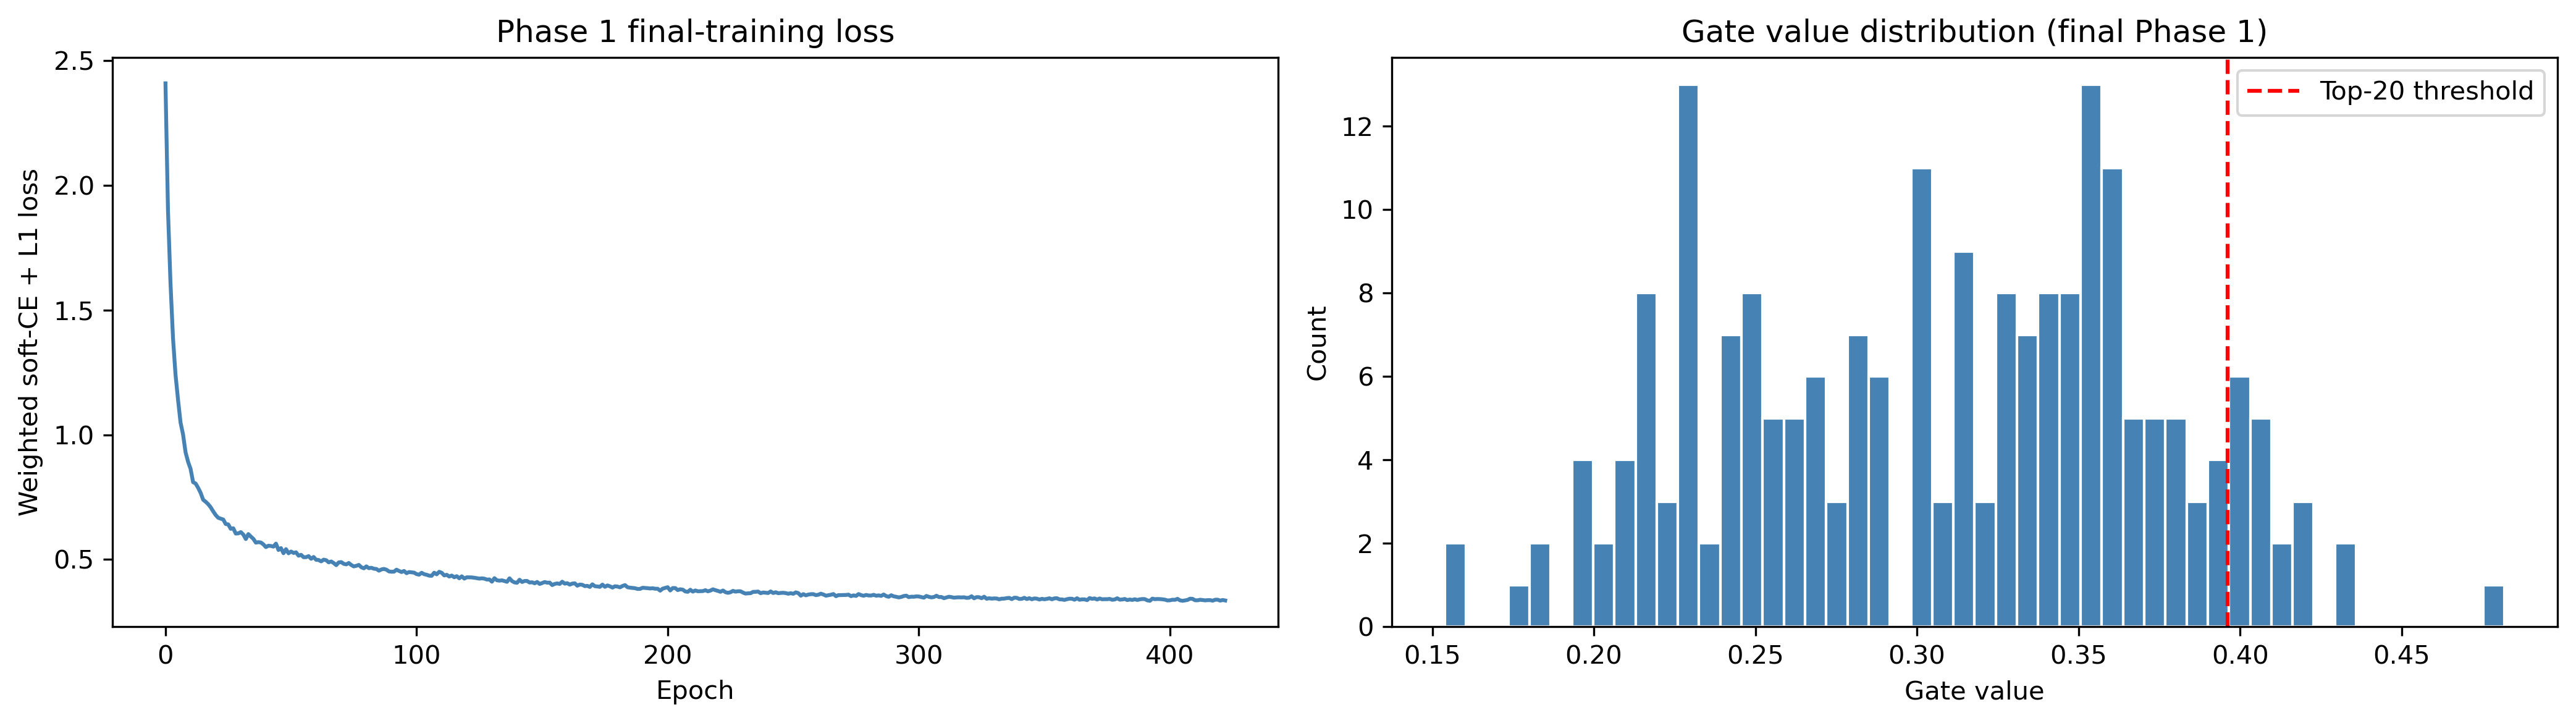

Phase 1 terminal accuracy (all)     : 0.8401
Phase 1 terminal accuracy (non-dead): 0.9785
Phase 1 terminal accuracy (dead)    : 0.0789
Phase 1 selector config   : {'l1_lambda': 0.002, 'hidden_dims': (128, 64), 'dropout': 0.3}
Phase 1 epochs run        : 423
Phase 2-chosen K          : 20
Selected 20 features: ['HLH-2_SYS1049', 'CEH-45_SYS634', 'CEH-27_SYS89', 'CEH-43_SYS90', 'LIM-6_SYS1052', 'NHR-25_RW10348', 'EGRH-1_SYS444', 'SOX-2_SYS516', 'HAM-2_SYS553', 'ZAG-1_SYS102', 'PHA-4_RW10425', 'MEP-1_SYS83', 'PAX-1_SYS104', 'COG-1_SYS144', 'ELT-6_SYS631', 'CEH-36_SYS653', 'CEH-34_SYS173', 'POP-1_SYS88', 'HLH-3_SYS222', 'CRH-2_SYS274']


In [20]:
# ─── Final Phase 1 training with CV-chosen selector and CV-chosen K ───────────
#

# Phase 1 is re-trained once on the full dataset using the best stability-aware
# selector configuration. The number of retained proteins comes from Phase 2 CV,
# where K was explicitly tuned against validation accuracy, soft-label fit, and
# model complexity.

# N_SELECT = 25 # override for some downstream tests

model_sparse, top_idx, gate_vals, _emb_p1, losses_p1 = train_one_pass(
    X_train, y_train, sample_weights_train,
    hidden_dims = best_selector_config['hidden_dims'],
    l1_lambda   = best_selector_config['l1_lambda'],
    dropout     = best_selector_config.get('dropout', 0.3),
    n_select    = N_SELECT,
    n_epochs    = 500,
    batch_size  = 127,
    device      = str(device),
    early_stopping_patience = FINAL_PHASE1_EARLY_STOPPING_PATIENCE,
)

X_sel   = X[:, top_idx].astype(np.float32)
X_sel_t = torch.FloatTensor(X_sel)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(losses_p1, color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted soft-CE + L1 loss')
ax.set_title('Phase 1 final-training loss')

ax = axes[1]
ax.hist(gate_vals, bins=50, color='steelblue', edgecolor='white')
ax.axvline(np.sort(gate_vals)[::-1][N_SELECT - 1], color='red', linestyle='--', label=f'Top-{N_SELECT} threshold')
ax.set_xlabel('Gate value')
ax.set_ylabel('Count')
ax.set_title('Gate value distribution (final Phase 1)')
ax.legend()

plt.tight_layout()
plt.show()

final_acc_p1 = eval_accuracy(model_sparse, torch.FloatTensor(X).to(device), y_t, term_t, device)
print(f"Phase 1 terminal accuracy (all)     : {final_acc_p1:.4f}")
if EXCLUDE_DEAD_CELLS:
    non_dead_term = term_t & ~torch.BoolTensor(dead_terminal_mask)
    dead_term = term_t & torch.BoolTensor(dead_terminal_mask)
    acc_non_dead = eval_accuracy(model_sparse, torch.FloatTensor(X).to(device), y_t, non_dead_term, device)
    acc_dead = eval_accuracy(model_sparse, torch.FloatTensor(X).to(device), y_t, dead_term, device)
    print(f"Phase 1 terminal accuracy (non-dead): {acc_non_dead:.4f}")
    print(f"Phase 1 terminal accuracy (dead)    : {acc_dead:.4f}")
print(f"Phase 1 selector config   : {best_selector_config}")
print(f"Phase 1 epochs run        : {len(losses_p1)}")
print(f"Phase 2-chosen K          : {N_SELECT}")
print(f"Selected {N_SELECT} features: {feature_names[top_idx].tolist()}")

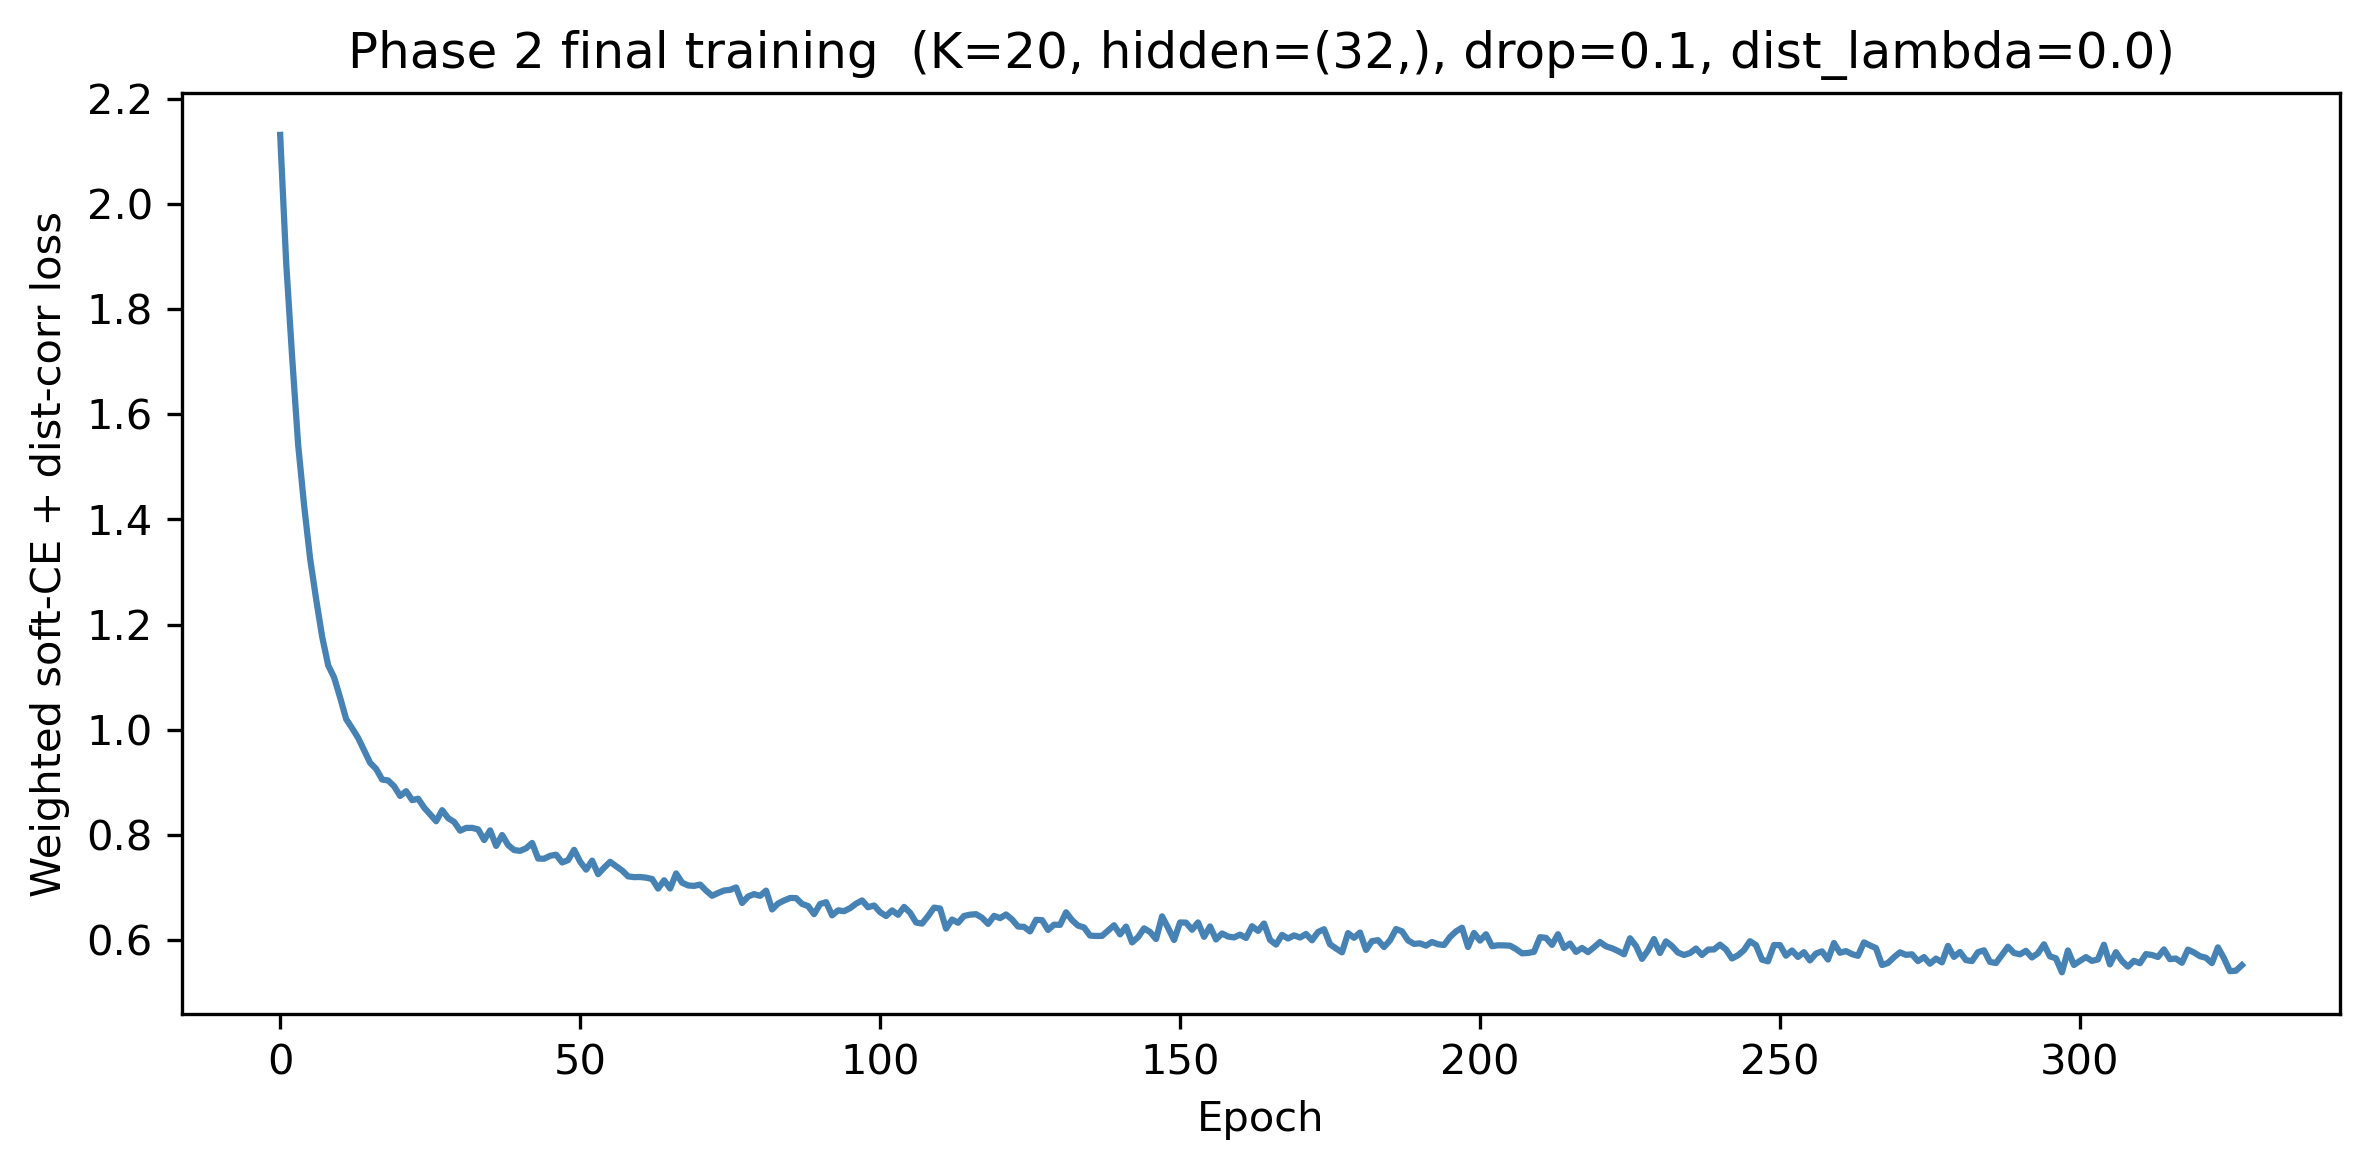

Phase 2 epochs run                    : 328

Final hard-label (terminal) accuracy   : 0.8097
Soft-label dominant-class agreement     : 0.7816
Soft-label expected target probability  : 0.6505
Soft-label cross-entropy               : 0.9734
Terminal accuracy (non-dead)            : 0.9545
Terminal accuracy (dead, unseen)        : 0.0132

Embedding shape : (1204, 32)  (n_samples × embed_dim)


In [21]:
# ─── Final Phase 2 training with CV-selected architecture ─────────────────────
#

DIST_LAMBDA    = best_phase2_config.get('dist_lambda', 0.1)
DIST_LAMBDA = best_phase2_config.get('dist_lambda', 0.1)
# DIST_LAMBDA = 0 # override for now
N_EPOCHS_P2    = 600
P2_HIDDEN_DIMS = best_phase2_config['hidden_dims']
P2_DROPOUT     = best_phase2_config.get('dropout', 0.2)

model_final, embeddings_train, losses_p2 = train_focused(
    X_sel[train_mask], y_train, sample_weights_train,
    hidden_dims = P2_HIDDEN_DIMS,
    dropout     = P2_DROPOUT,
    n_epochs    = N_EPOCHS_P2,
    batch_size  = 63,
    seed        = 42,
    device      = str(device),
    dist_lambda = DIST_LAMBDA,
    early_stopping_patience = FINAL_PHASE2_EARLY_STOPPING_PATIENCE,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses_p2, color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted soft-CE + dist-corr loss')
ax.set_title(
    f'Phase 2 final training  (K={N_SELECT}, hidden={P2_HIDDEN_DIMS}, '
    f'drop={P2_DROPOUT}, dist_lambda={DIST_LAMBDA})'
 )
plt.tight_layout()
plt.show()

# Get embeddings for ALL cells (including excluded dead cells)
model_final.eval()
with torch.no_grad():
    _, emb_all_t = model_final(X_sel_t.to(device))
embeddings = emb_all_t.cpu().numpy()

terminal_metrics = eval_prediction_metrics(
    model_final, X_sel_t, y_t, term_t, device,
 )
all_metrics = eval_prediction_metrics(
    model_final, X_sel_t, y_t, None, device, sample_weights=sample_weights_v2,
 )

print(f"Phase 2 epochs run                    : {len(losses_p2)}")
print(f"\nFinal hard-label (terminal) accuracy   : {terminal_metrics['argmax_accuracy']:.4f}")
print(f"Soft-label dominant-class agreement     : {all_metrics['argmax_accuracy']:.4f}")
print(f"Soft-label expected target probability  : {all_metrics['expected_target_probability']:.4f}")
print(f"Soft-label cross-entropy               : {all_metrics['soft_cross_entropy']:.4f}")
if EXCLUDE_DEAD_CELLS:
    non_dead_term = term_t & ~torch.BoolTensor(dead_terminal_mask)
    dead_term = term_t & torch.BoolTensor(dead_terminal_mask)
    metrics_non_dead = eval_prediction_metrics(model_final, X_sel_t, y_t, non_dead_term, device)
    metrics_dead = eval_prediction_metrics(model_final, X_sel_t, y_t, dead_term, device)
    print(f"Terminal accuracy (non-dead)            : {metrics_non_dead['argmax_accuracy']:.4f}")
    print(f"Terminal accuracy (dead, unseen)        : {metrics_dead['argmax_accuracy']:.4f}")
print(f"\nEmbedding shape : {embeddings.shape}  (n_samples × embed_dim)")

### How to read the accuracy numbers

For terminal nodes, the labels are one-hot, so `argmax_accuracy` is ordinary classification accuracy.

For all nodes, many labels are soft mixtures over cell types. In that setting, `argmax_accuracy` only tells you whether the model picked the dominant component of the target distribution.

The more faithful soft-label metrics are:

- `expected_target_probability`: how much predicted probability mass lands on the full target distribution.
- `soft_cross_entropy`: the training-aligned loss against the full target distribution, where lower is better.

In practice, use terminal `argmax_accuracy` for hard-label discrimination and inspect the soft metrics to judge whether intermediate nodes are modeled well.

Hard-label terminal accuracy        : 0.8097
Soft-label dominant-class agreement : 0.7816
Soft-label expected target prob.    : 0.6505
Soft-label cross-entropy            : 0.9734

Cell type                         Acc  n
---------------------------------------------
  muscle                        1.000  110
  alimentary                    1.000  21
  excretory                     1.000  4
  neuron                        0.976  167
  glial                         0.975  40
  epithelium                    0.969  64
  programmed_death              0.013  76
  other                         0.000  9
  mesoderm                      0.000  1
  reproduction                  0.000  2


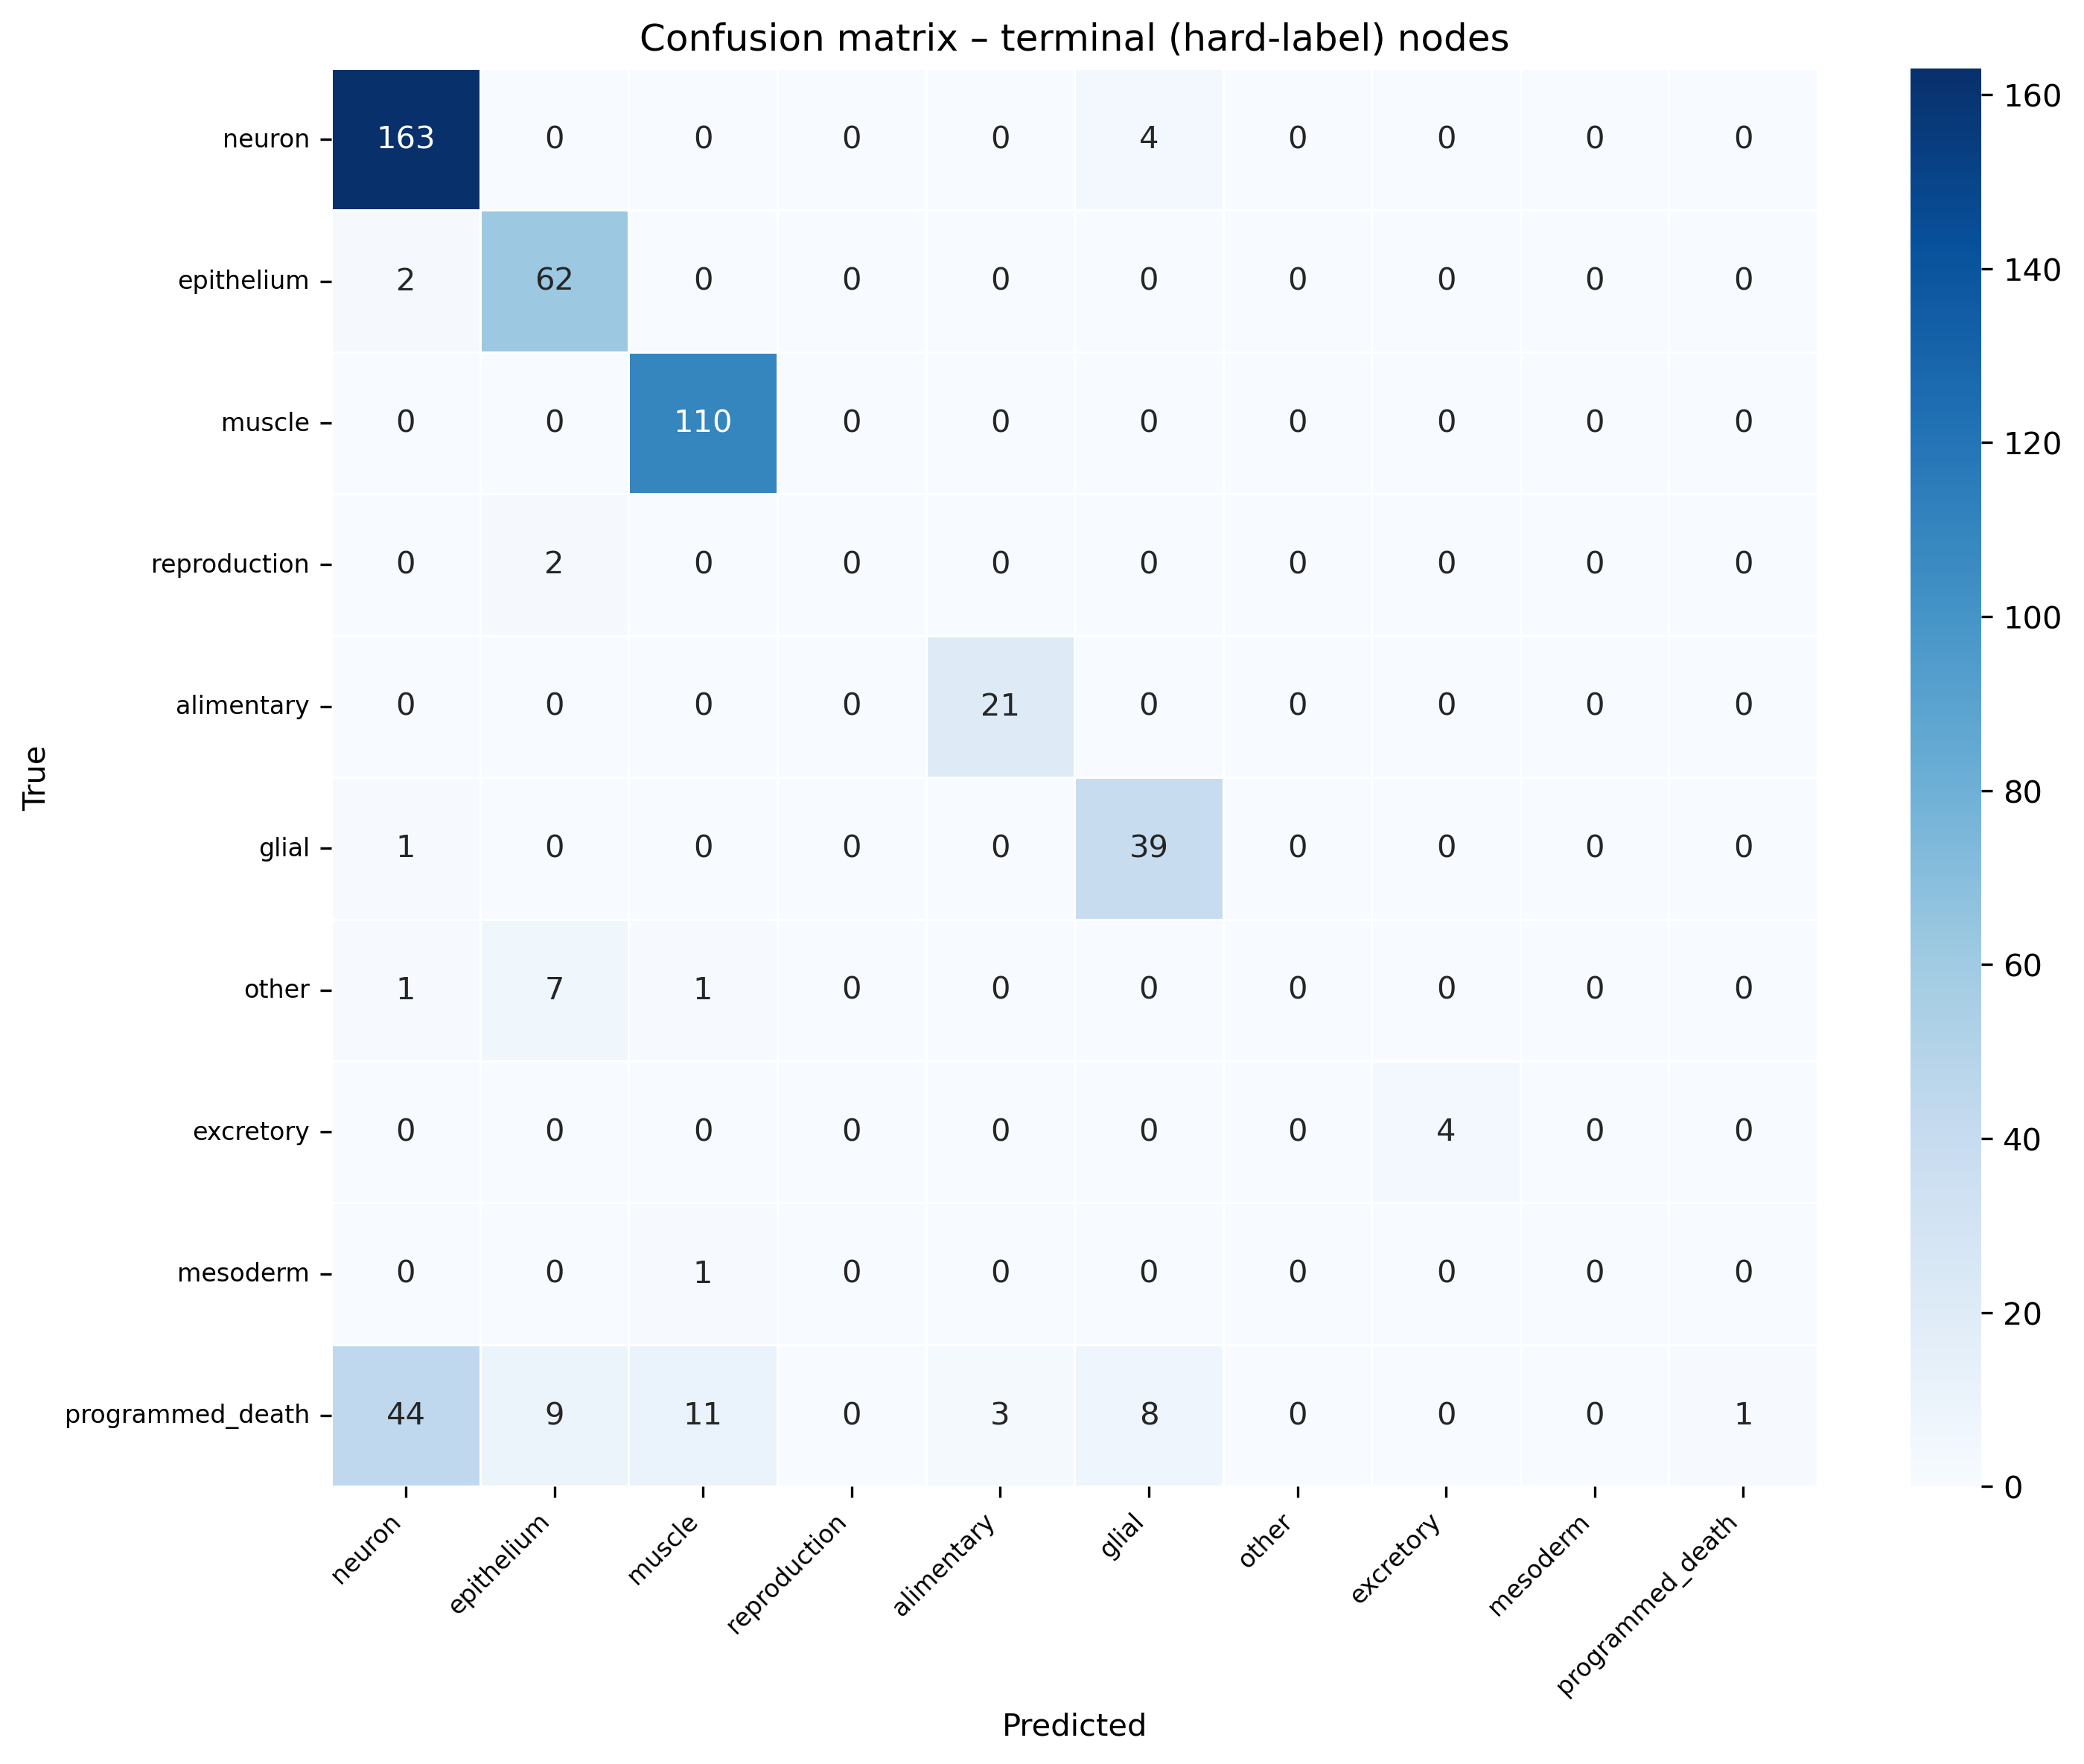

In [22]:
# ─── Evaluation: confusion matrix on hard-label (terminal) nodes ──────────────

model_final.eval()
with torch.no_grad():
    logits_all, _ = model_final(X_sel_t.to(device))
    probs_all = F.softmax(logits_all, dim=-1).cpu().numpy()

preds_all   = probs_all.argmax(axis=1)
targets_all = y.argmax(axis=1)

term_preds   = preds_all[terminal_mask]
term_targets = targets_all[terminal_mask]

terminal_metrics = eval_prediction_metrics(
    model_final, X_sel_t, y_t, term_t, device,
 )
all_metrics = eval_prediction_metrics(
    model_final, X_sel_t, y_t, None, device, sample_weights=sample_weights_v2,
 )

print(f"Hard-label terminal accuracy        : {terminal_metrics['argmax_accuracy']:.4f}")
print(f"Soft-label dominant-class agreement : {all_metrics['argmax_accuracy']:.4f}")
print(f"Soft-label expected target prob.    : {all_metrics['expected_target_probability']:.4f}")
print(f"Soft-label cross-entropy            : {all_metrics['soft_cross_entropy']:.4f}\n")

# Per-cell-type breakdown on true hard-label terminal samples
per_type = defaultdict(list)
for p, t in zip(term_preds, term_targets):
    per_type[cell_types[t]].append(p == t)

print(f"{'Cell type':30s}  {'Acc':>5}  n")
print("-" * 45)
for ct, vals in sorted(per_type.items(), key=lambda x: -np.mean(x[1])):
    print(f"  {ct:28s}  {np.mean(vals):.3f}  {len(vals)}")

present_types = sorted(np.unique(term_targets).tolist())
conf = np.zeros((len(present_types), len(present_types)), dtype=int)
t2i  = {t: i for i, t in enumerate(present_types)}
for p, t in zip(term_preds, term_targets):
    if p in t2i:
        conf[t2i[t], t2i[p]] += 1

ct_labels = [cell_types[i] for i in present_types]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=ct_labels, yticklabels=ct_labels, ax=ax,
            linewidths=0.3)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix – terminal (hard-label) nodes')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Embedding matrix: (1204, 32)  (n_cells × embed_dim)
Cell names: ['ABa' 'ABal' 'ABala' 'ABalaa' 'ABalaaa'] ...


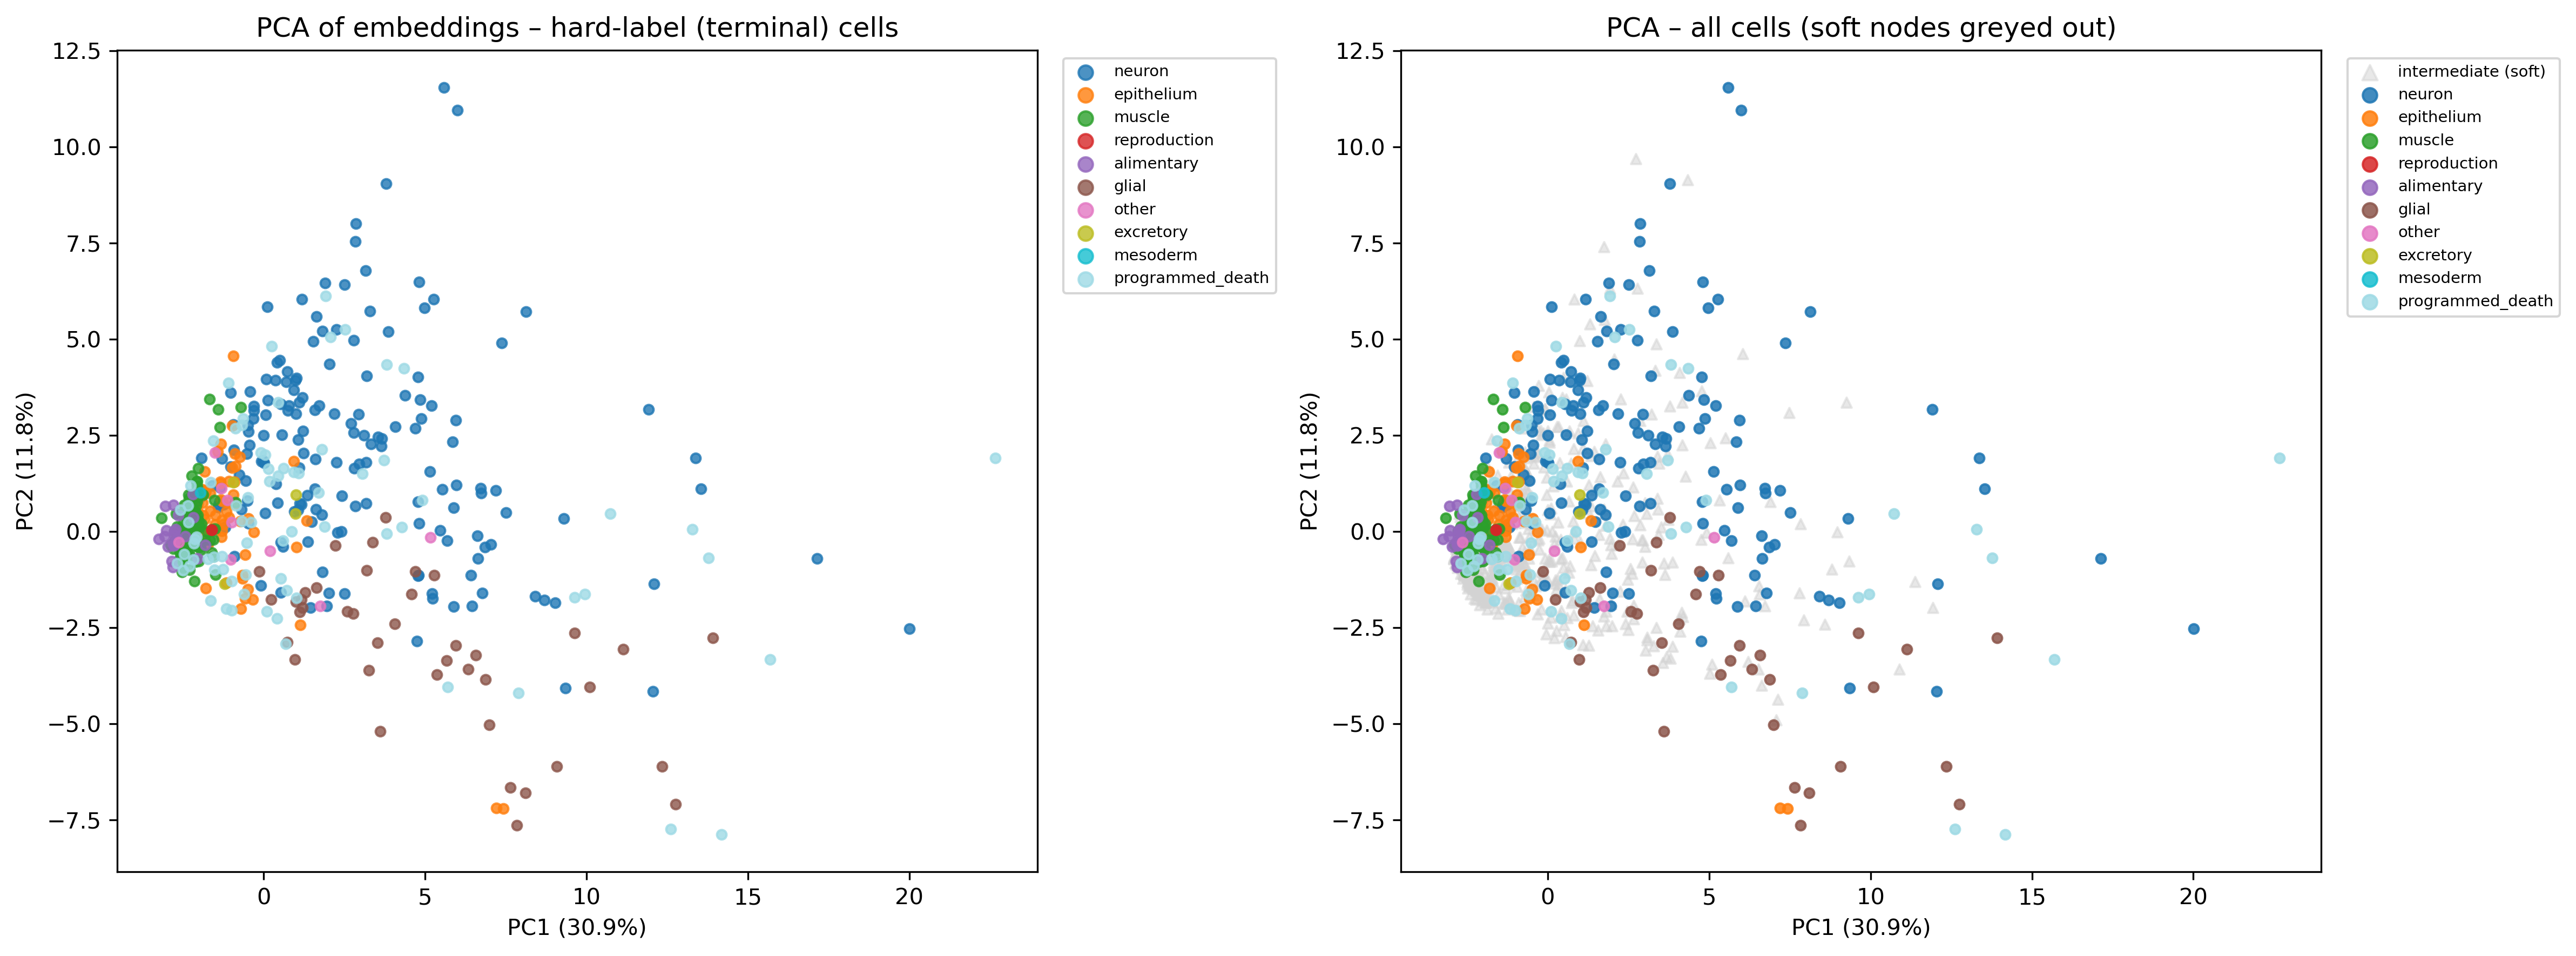

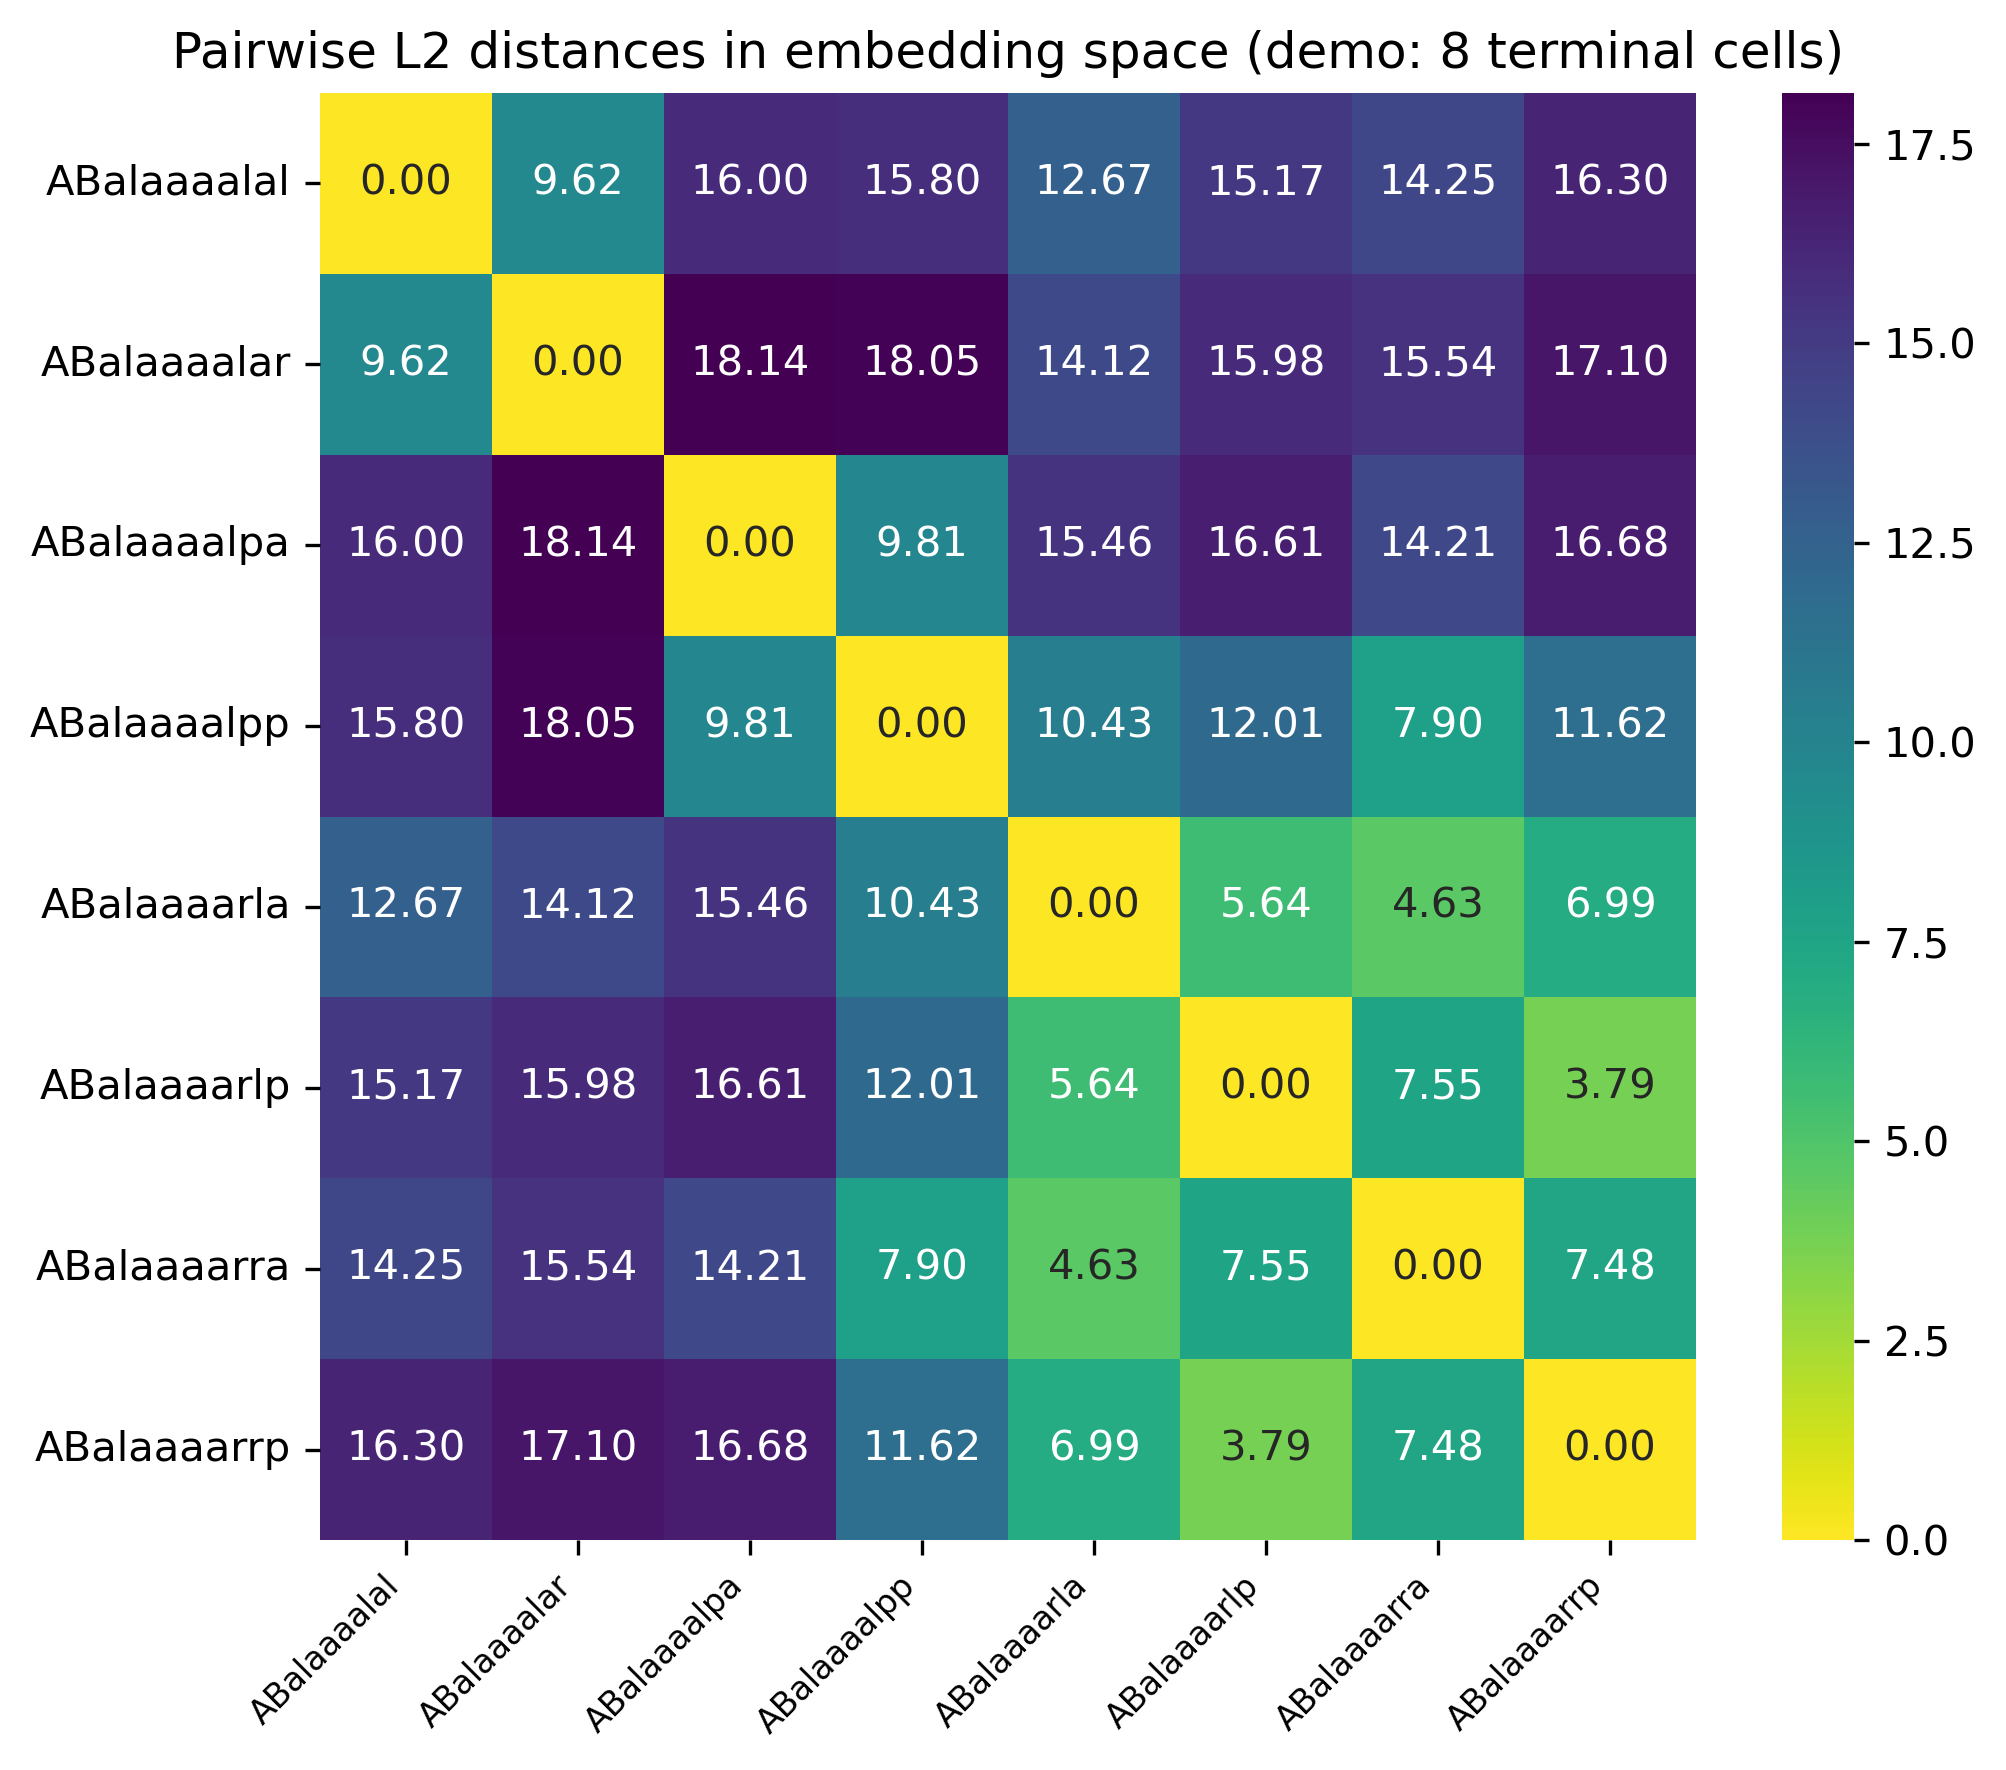


To compute all pairwise distances:
  dist_all    = cdist(embeddings, embeddings, metric='euclidean')
  dist_cosine = cdist(embeddings, embeddings, metric='cosine')

Embedding array: `embeddings`  shape=(1204, 32)
Cell names     : `cell_names`  n=1204


In [23]:

from matplotlib.lines import Line2D

# ─── Embeddings for downstream distance analysis ─────────────────────────────
#
# `embeddings` (n_samples × embed_dim) is already produced by train_one_pass().
# The penultimate layer of the one-pass SparseGateClassifier is used directly —
# no separate FocusedClassifier needed.
#
# Properties:
#   • Trained with soft-label supervision → intermediate nodes land between
#     their descendant terminal nodes in embedding space.
#   • Weighted training → distances among terminal nodes are most reliable.
#   • embed_dim = last element of best_config['hidden_dims'] (flexible).

cell_names = np.array([map_names(n) for n in protein_exp_zscore.columns])

print(f"Embedding matrix: {embeddings.shape}  (n_cells × embed_dim)")
print(f"Cell names: {cell_names[:5]} ...")

# ── PCA visualisation ─────────────────────────────────────────────────────────
pca    = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)
ct_idx = y.argmax(axis=1)

# Shared color mapping for cell types across both panels.
cmap = plt.get_cmap('tab20', len(cell_types))
cell_type_colors = {ct: cmap(i) for i, ct in enumerate(cell_types)}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hard-label nodes coloured by cell type using the shared palette
ax = axes[0]
for i, ct in enumerate(cell_types):
    mask_ct = (ct_idx == i) & terminal_mask
    if mask_ct.sum() > 0:
        ax.scatter(
            emb_2d[mask_ct, 0],
            emb_2d[mask_ct, 1],
            label=ct,
            s=18,
            alpha=0.8,
            color=cell_type_colors[ct],
            marker='o',
        )
ax.set_title('PCA of embeddings – hard-label (terminal) cells')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, markerscale=1.5)

# All cells: soft nodes in grey triangles, hard nodes keep the same colors
ax = axes[1]
ax.scatter(
    emb_2d[~terminal_mask, 0],
    emb_2d[~terminal_mask, 1],
    color='lightgray',
    s=20,
    alpha=0.5,
    marker='^',
    label='intermediate (soft)',
)
for i, ct in enumerate(cell_types):
    mask_ct = (ct_idx == i) & terminal_mask
    if mask_ct.sum() > 0:
        ax.scatter(
            emb_2d[mask_ct, 0],
            emb_2d[mask_ct, 1],
            color=cell_type_colors[ct],
            s=18,
            alpha=0.85,
            marker='o',
            label=ct,
        )
ax.set_title('PCA – all cells (soft nodes greyed out)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, markerscale=1.5)

plt.tight_layout()
plt.show()

# ── Example: pairwise L2 distances among a handful of terminal cells ──────────
from scipy.spatial.distance import cdist

demo_idx   = np.where(terminal_mask)[0][:8]
demo_names = cell_names[demo_idx]
demo_emb   = embeddings[demo_idx]

dist_mat = cdist(demo_emb, demo_emb, metric='euclidean')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_mat, annot=True, fmt='.2f', cmap='viridis_r',
            xticklabels=demo_names, yticklabels=demo_names, ax=ax)
ax.set_title('Pairwise L2 distances in embedding space (demo: 8 terminal cells)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print("\nTo compute all pairwise distances:")
print("  dist_all    = cdist(embeddings, embeddings, metric='euclidean')")
print("  dist_cosine = cdist(embeddings, embeddings, metric='cosine')")
print(f"\nEmbedding array: `embeddings`  shape={embeddings.shape}")
print(f"Cell names     : `cell_names`  n={len(cell_names)}")


Total terminal-sibling pairs in data: 209
  Same cell type : 106
  Diff cell type : 103

Same-type sibling distance:  mean=3.273  median=2.754  std=2.443
Diff-type sibling distance:  mean=4.848  median=4.512  std=2.002

Mann-Whitney U (same < diff): U=2641, p=5.75e-11
KS test (distributions differ): D=0.454, p=3.14e-10


/tmp/ipykernel_1149397/1782416390.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=['Same type'] * len(same_dists) + ['Diff type'] * len(diff_dists),


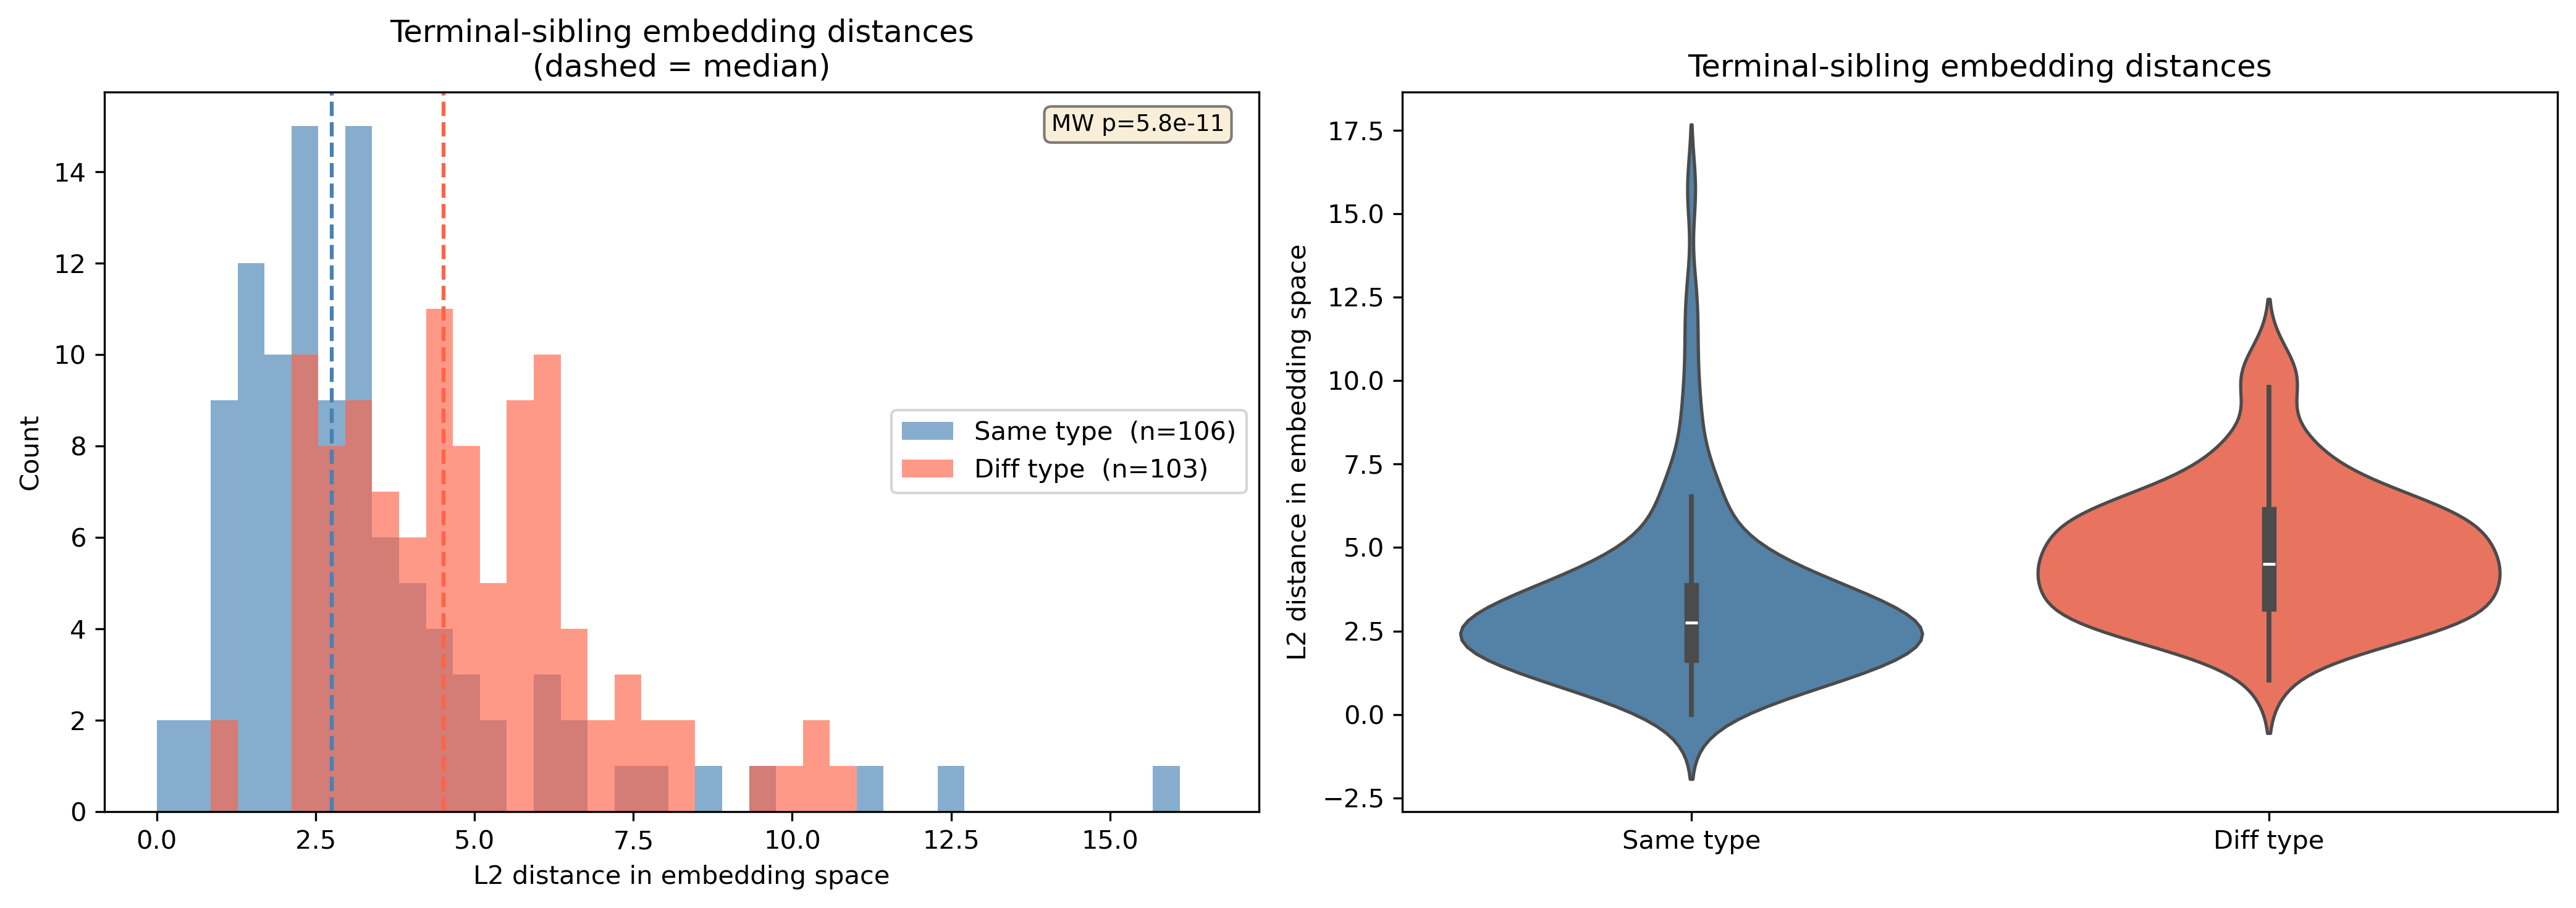


Same-type sibling distances by cell type:
  Type                              n    mean   median
  ----------------------------------------------------
  reproduction                      1   0.000    0.000
  alimentary                        3   1.843    2.026
  muscle                           38   2.030    2.071
  epithelium                       17   3.150    2.766
  other                             2   3.695    3.695
  neuron                           42   4.319    3.566
  glial                             3   7.325    6.667


In [24]:

# ─── Sanity check: embedding distance for terminal siblings ──────────────────
#
# Hypothesis: same-type sibling pairs should have SMALLER embedding distance
# than different-type sibling pairs, because the classifier was trained to
# separate cell types.
#
# "Terminal siblings" = two terminal nodes that share the same direct parent.

# ── 1. Build parent→children map from the lineage tree ────────────────────────
children_dict_lin = defaultdict(list)   # parent_name → [child_names]
parent_dict_lin   = {}                  # child_name  → parent_name

def build_family(node, parent_name=None):
    name = map_names(node["did"])
    if parent_name is not None:
        parent_dict_lin[name] = parent_name
        children_dict_lin[parent_name].append(name)
    for child in node.get("children", []):
        build_family(child, name)

build_family(lineage_data)

# ── 2. Collect terminal-sibling pairs that are in the protein_exp data ─────────
# cell_names is the array of mapped cell names from protein_exp columns
cell_name_to_idx = {name: i for i, name in enumerate(cell_names)}
terminal_set     = set(cell_names[terminal_mask])   # terminal nodes present in data

sibling_pairs = []   # list of (nameA, nameB, same_type: bool)

for parent, children in children_dict_lin.items():
    term_children = [c for c in children if c in terminal_set]
    # All pairs among terminal children of this parent
    for i in range(len(term_children)):
        for j in range(i + 1, len(term_children)):
            a, b = term_children[i], term_children[j]
            type_a = cell_type_dict.get(a)
            type_b = cell_type_dict.get(b)
            if type_a is None or type_b is None:
                continue
            sibling_pairs.append((a, b, type_a == type_b))

same_pairs = [(a, b) for a, b, s in sibling_pairs if     s]
diff_pairs = [(a, b) for a, b, s in sibling_pairs if not s]
print(f"Total terminal-sibling pairs in data: {len(sibling_pairs)}")
print(f"  Same cell type : {len(same_pairs)}")
print(f"  Diff cell type : {len(diff_pairs)}")

# ── 3. Compute embedding distances ────────────────────────────────────────────
def pair_distance(a, b):
    ia, ib = cell_name_to_idx[a], cell_name_to_idx[b]
    return float(np.linalg.norm(embeddings[ia] - embeddings[ib]))

same_dists = np.array([pair_distance(a, b) for a, b in same_pairs])
diff_dists = np.array([pair_distance(a, b) for a, b in diff_pairs])

print(f"\nSame-type sibling distance:  mean={same_dists.mean():.3f}  median={np.median(same_dists):.3f}  std={same_dists.std():.3f}")
print(f"Diff-type sibling distance:  mean={diff_dists.mean():.3f}  median={np.median(diff_dists):.3f}  std={diff_dists.std():.3f}")

# Mann-Whitney U test (non-parametric, no normality assumption)
from scipy.stats import mannwhitneyu, ks_2samp
u_stat, p_mw = mannwhitneyu(same_dists, diff_dists, alternative='less')
ks_stat, p_ks = ks_2samp(same_dists, diff_dists)
print(f"\nMann-Whitney U (same < diff): U={u_stat:.0f}, p={p_mw:.2e}")
print(f"KS test (distributions differ): D={ks_stat:.3f}, p={p_ks:.2e}")

# ── 4. Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlapping histograms
ax = axes[0]
bins = np.linspace(0, max(same_dists.max(), diff_dists.max()) * 1.05, 40)
ax.hist(same_dists, bins=bins, alpha=0.65, color='steelblue',  label=f'Same type  (n={len(same_dists)})')
ax.hist(diff_dists, bins=bins, alpha=0.65, color='tomato',     label=f'Diff type  (n={len(diff_dists)})')
ax.axvline(np.median(same_dists), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(np.median(diff_dists), color='tomato',    linestyle='--', linewidth=1.5)
ax.set_xlabel('L2 distance in embedding space')
ax.set_ylabel('Count')
ax.set_title('Terminal-sibling embedding distances\n(dashed = median)')
ax.legend()
ax.text(0.97, 0.97, f'MW p={p_mw:.1e}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# violinplot
ax = axes[1]
sns.violinplot(x=['Same type'] * len(same_dists) + ['Diff type'] * len(diff_dists),
               y=np.concatenate([same_dists, diff_dists]),
               palette=['steelblue', 'tomato'], ax=ax)
ax.set_ylabel('L2 distance in embedding space')
ax.set_title('Terminal-sibling embedding distances')

plt.tight_layout()
plt.show()

# ── 5. Per-type breakdown for same-type pairs ─────────────────────────────────
type_pair_dists = defaultdict(list)
for a, b, same in sibling_pairs:
    if same:
        t = cell_type_dict[a]
        type_pair_dists[t].append(pair_distance(a, b))

print("\nSame-type sibling distances by cell type:")
print(f"  {'Type':30s}  {'n':>3}  {'mean':>6}  {'median':>7}")
print("  " + "-" * 52)
for t, dists in sorted(type_pair_dists.items(), key=lambda x: np.mean(x[1])):
    print(f"  {t:30s}  {len(dists):3d}  {np.mean(dists):6.3f}  {np.median(dists):7.3f}")


Original 20-feature space:
  Same-type sibling distance: mean=2.109  median=1.536  std=1.782
  Diff-type sibling distance: mean=3.123  median=2.951  std=1.428
  Mann-Whitney U (same < diff): U=2745, p=2.69e-10
  KS test (distributions differ): D=0.485, p=1.01e-11
  Median ratio (diff/same): 1.921
  Cohen's d: 0.624
  AUC-like separation: 0.749

Distance correlation (Phase 2 embedding vs. selected-feature space, terminal cells only):
  Pearson  r = 0.7006
  Spearman r = 0.8094


,space,same_median,diff_median,median_ratio,cohen_d,auc_like,mw_pvalue
0,Selected 20 features,1.5364,2.9512,1.9209,0.6240,0.7486,0.0
1,32D embedding,2.7540,4.5120,1.6384,0.7005,0.7581,0.0


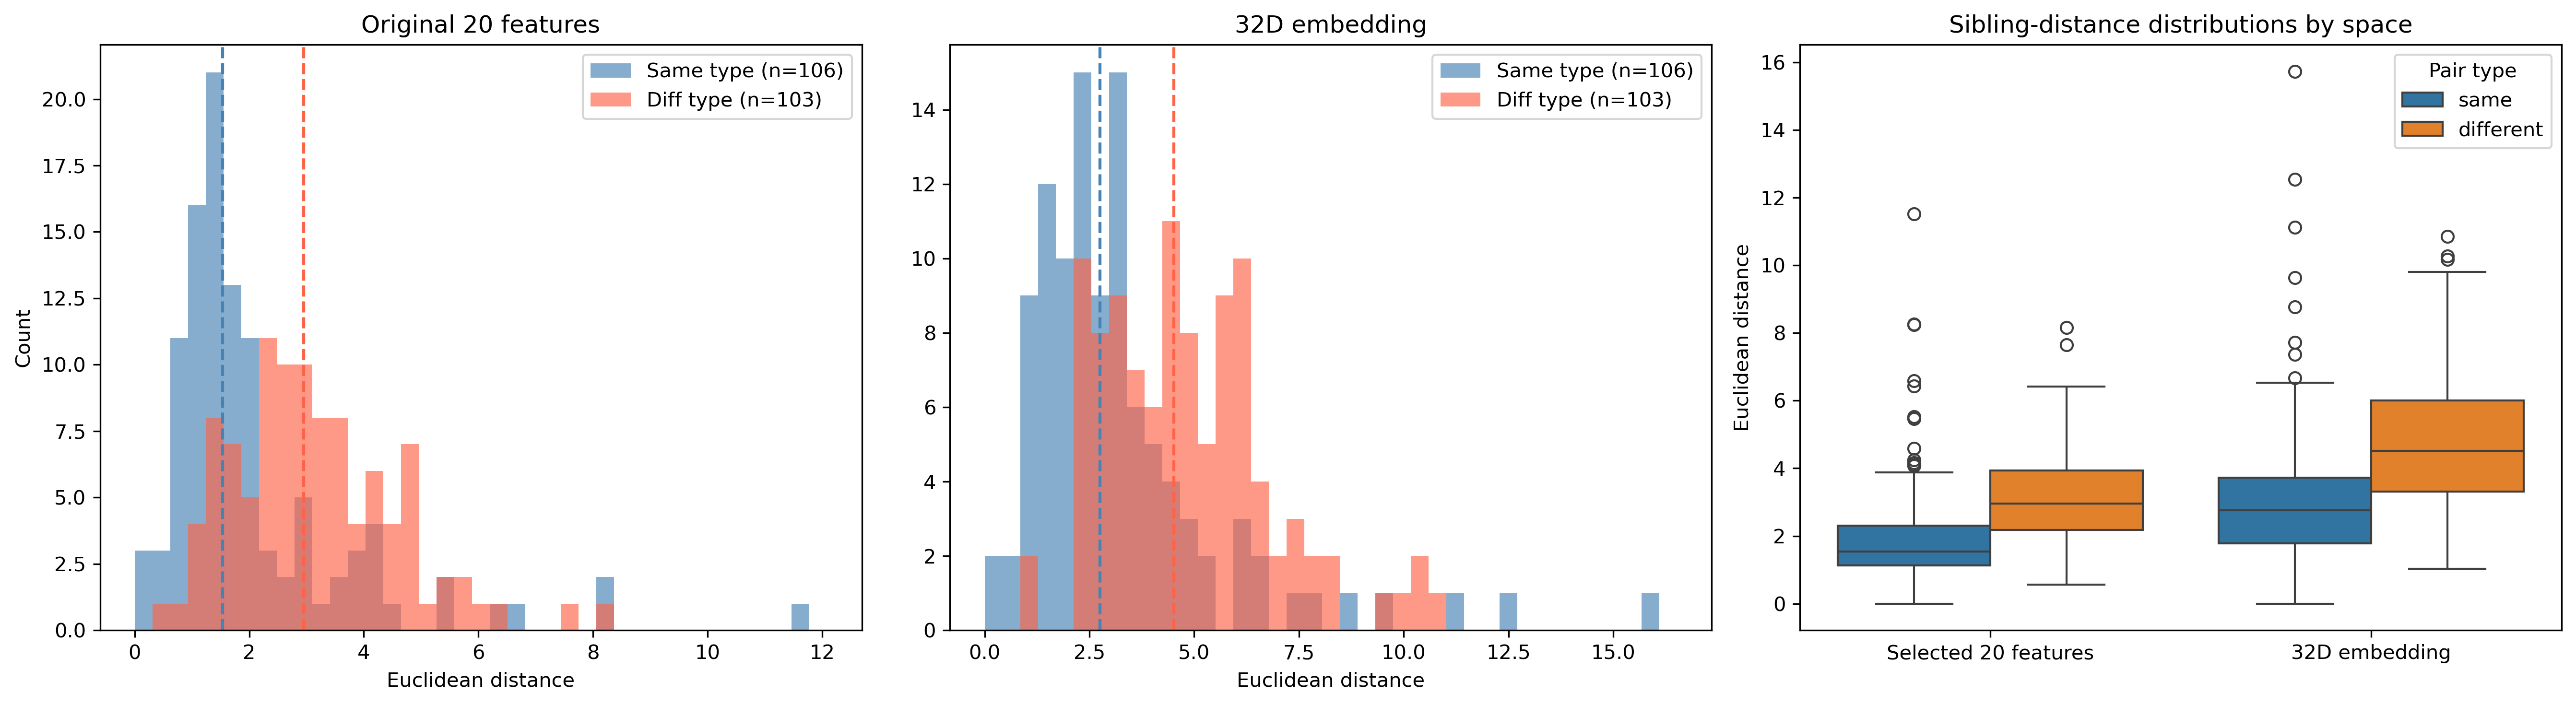


Same-type sibling distances by cell type in the original 20-feature space:
  Type                              n    mean   median
  ----------------------------------------------------
  reproduction                      1   0.000    0.000
  muscle                           38   1.177    1.147
  alimentary                        3   1.706    1.398
  epithelium                       17   2.127    1.770
  other                             2   2.513    2.513
  neuron                           42   2.832    1.951
  glial                             3   4.538    4.249

Interpretation: the original 20-feature space preserves most of the sibling-type separation signal seen in the learned embedding.


In [25]:

# ─── Sanity check: sibling distances in the original selected-feature space ─────
#
# Question: do the N_SELECT selected protein features already separate
# same-type vs different-type terminal siblings in a way similar to the
# learned embedding?  And does the dist_lambda regularisation in Phase 2
# improve the correlation between the two spaces?

from scipy.stats import mannwhitneyu, ks_2samp

def pair_distance_in_space(a, b, representation, name_to_idx):
    ia, ib = name_to_idx[a], name_to_idx[b]
    return float(np.linalg.norm(representation[ia] - representation[ib]))

selected_feature_repr = X_sel
selected_same_dists = np.array([
    pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
    for a, b in same_pairs
])
selected_diff_dists = np.array([
    pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
    for a, b in diff_pairs
])

u_feat, p_feat     = mannwhitneyu(selected_same_dists, selected_diff_dists, alternative='less')
ks_feat, p_ks_feat = ks_2samp(selected_same_dists, selected_diff_dists)

def separation_summary(same_dists, diff_dists, u_stat):
    n_same = len(same_dists)
    n_diff = len(diff_dists)
    pooled_std = np.sqrt(
        ((n_same - 1) * same_dists.std(ddof=1) ** 2 + (n_diff - 1) * diff_dists.std(ddof=1) ** 2)
        / (n_same + n_diff - 2)
    )
    cohen_d = (diff_dists.mean() - same_dists.mean()) / pooled_std
    auc = 1.0 - (u_stat / (n_same * n_diff))
    return {
        'same_mean': same_dists.mean(),
        'same_median': np.median(same_dists),
        'diff_mean': diff_dists.mean(),
        'diff_median': np.median(diff_dists),
        'median_ratio': np.median(diff_dists) / np.median(same_dists),
        'cohen_d': cohen_d,
        'auc_like': auc,
    }

embed_dim_label   = f'{embeddings.shape[1]}D embedding'
embedding_summary = separation_summary(same_dists, diff_dists, u_stat)
feature_summary   = separation_summary(selected_same_dists, selected_diff_dists, u_feat)

print(f'Original {N_SELECT}-feature space:')
print(f"  Same-type sibling distance: mean={feature_summary['same_mean']:.3f}  median={feature_summary['same_median']:.3f}  std={selected_same_dists.std():.3f}")
print(f"  Diff-type sibling distance: mean={feature_summary['diff_mean']:.3f}  median={feature_summary['diff_median']:.3f}  std={selected_diff_dists.std():.3f}")
print(f"  Mann-Whitney U (same < diff): U={u_feat:.0f}, p={p_feat:.2e}")
print(f"  KS test (distributions differ): D={ks_feat:.3f}, p={p_ks_feat:.2e}")
print(f"  Median ratio (diff/same): {feature_summary['median_ratio']:.3f}")
print(f"  Cohen's d: {feature_summary['cohen_d']:.3f}")
print(f"  AUC-like separation: {feature_summary['auc_like']:.3f}")

# ── Mantel-style correlation: how well do embedding distances track feature distances? ──
all_term_idx   = np.where(terminal_mask)[0]
term_feat_dists = squareform(pdist(X_sel[all_term_idx], metric='euclidean'))
term_emb_dists  = squareform(pdist(embeddings[all_term_idx], metric='euclidean'))
upper_tri = np.triu_indices(len(all_term_idx), k=1)
from scipy.stats import pearsonr, spearmanr as sp_r
r_pearson, _  = pearsonr( term_feat_dists[upper_tri], term_emb_dists[upper_tri])
r_spearman, _ = sp_r(     term_feat_dists[upper_tri], term_emb_dists[upper_tri])
print(f"\nDistance correlation (Phase 2 embedding vs. selected-feature space, terminal cells only):")
print(f"  Pearson  r = {r_pearson:.4f}")
print(f"  Spearman r = {r_spearman:.4f}")

comparison_df = pd.DataFrame(
    [
        {
            'space': f'Selected {N_SELECT} features',
            'same_median': feature_summary['same_median'],
            'diff_median': feature_summary['diff_median'],
            'median_ratio': feature_summary['median_ratio'],
            'cohen_d': feature_summary['cohen_d'],
            'auc_like': feature_summary['auc_like'],
            'mw_pvalue': p_feat,
        },
        {
            'space': embed_dim_label,
            'same_median': embedding_summary['same_median'],
            'diff_median': embedding_summary['diff_median'],
            'median_ratio': embedding_summary['median_ratio'],
            'cohen_d': embedding_summary['cohen_d'],
            'auc_like': embedding_summary['auc_like'],
            'mw_pvalue': p_mw,
        },
    ]
)
display(comparison_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bins_feat = np.linspace(
    0, max(selected_same_dists.max(), selected_diff_dists.max()) * 1.05, 40
)
axes[0].hist(selected_same_dists, bins=bins_feat, alpha=0.65, color='steelblue',
             label=f'Same type (n={len(selected_same_dists)})')
axes[0].hist(selected_diff_dists, bins=bins_feat, alpha=0.65, color='tomato',
             label=f'Diff type (n={len(selected_diff_dists)})')
axes[0].axvline(np.median(selected_same_dists), color='steelblue', linestyle='--', linewidth=1.5)
axes[0].axvline(np.median(selected_diff_dists), color='tomato', linestyle='--', linewidth=1.5)
axes[0].set_title(f'Original {N_SELECT} features')
axes[0].set_xlabel('Euclidean distance')
axes[0].set_ylabel('Count')
axes[0].legend()

bins_emb = np.linspace(0, max(same_dists.max(), diff_dists.max()) * 1.05, 40)
axes[1].hist(same_dists, bins=bins_emb, alpha=0.65, color='steelblue',
             label=f'Same type (n={len(same_dists)})')
axes[1].hist(diff_dists, bins=bins_emb, alpha=0.65, color='tomato',
             label=f'Diff type (n={len(diff_dists)})')
axes[1].axvline(np.median(same_dists), color='steelblue', linestyle='--', linewidth=1.5)
axes[1].axvline(np.median(diff_dists), color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_title(embed_dim_label)
axes[1].set_xlabel('Euclidean distance')
axes[1].legend()

comparison_long = pd.DataFrame({
    'distance': np.concatenate([selected_same_dists, selected_diff_dists, same_dists, diff_dists]),
    'pair_type': (['same'] * len(selected_same_dists) + ['different'] * len(selected_diff_dists) +
                  ['same'] * len(same_dists) + ['different'] * len(diff_dists)),
    'space': ([f'Selected {N_SELECT} features'] * (len(selected_same_dists) + len(selected_diff_dists)) +
              [embed_dim_label] * (len(same_dists) + len(diff_dists)))
})
sns.boxplot(data=comparison_long, x='space', y='distance', hue='pair_type', ax=axes[2])
axes[2].set_title('Sibling-distance distributions by space')
axes[2].set_xlabel('')
axes[2].set_ylabel('Euclidean distance')
axes[2].legend(title='Pair type')

plt.tight_layout()
plt.show()

feature_type_pair_dists = defaultdict(list)
for a, b, same in sibling_pairs:
    if same:
        t = cell_type_dict[a]
        feature_type_pair_dists[t].append(
            pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
        )

print(f'\nSame-type sibling distances by cell type in the original {N_SELECT}-feature space:')
print(f"  {'Type':30s}  {'n':>3}  {'mean':>6}  {'median':>7}")
print('  ' + '-' * 52)
for t, dists in sorted(feature_type_pair_dists.items(), key=lambda x: np.mean(x[1])):
    print(f"  {t:30s}  {len(dists):3d}  {np.mean(dists):6.3f}  {np.median(dists):7.3f}")

if feature_summary['auc_like'] >= embedding_summary['auc_like'] - 0.02:
    print(f'\nInterpretation: the original {N_SELECT}-feature space preserves most of the sibling-type separation signal seen in the learned embedding.')
else:
    print(f'\nInterpretation: the {embed_dim_label} sharpens sibling-type separation beyond what is already present in the raw {N_SELECT} selected features.')


Terminal cells: 494 | total terminal pairs: 121771
Intra-type pairs: 25755 | Inter-type pairs: 96016



,space,n_same_pairs,n_diff_pairs,same_mean,same_median,same_std,diff_mean,diff_median,diff_std,median_ratio_diff_over_same,cohen_d,auc_like,mw_u,mw_pvalue_same_less_diff,ks_d,ks_pvalue
0,Selected 20 proteins,25755,96016,6.2544,5.5168,3.8370,7.2094,6.5079,3.8215,1.1797,0.2497,0.5875,1.020039e+09,0.0,0.1344,0.0
1,Learned embedding (32D),25755,96016,8.3132,7.5590,4.1327,9.5844,8.7126,4.0513,1.1526,0.3125,0.5967,9.973500e+08,0.0,0.1503,0.0


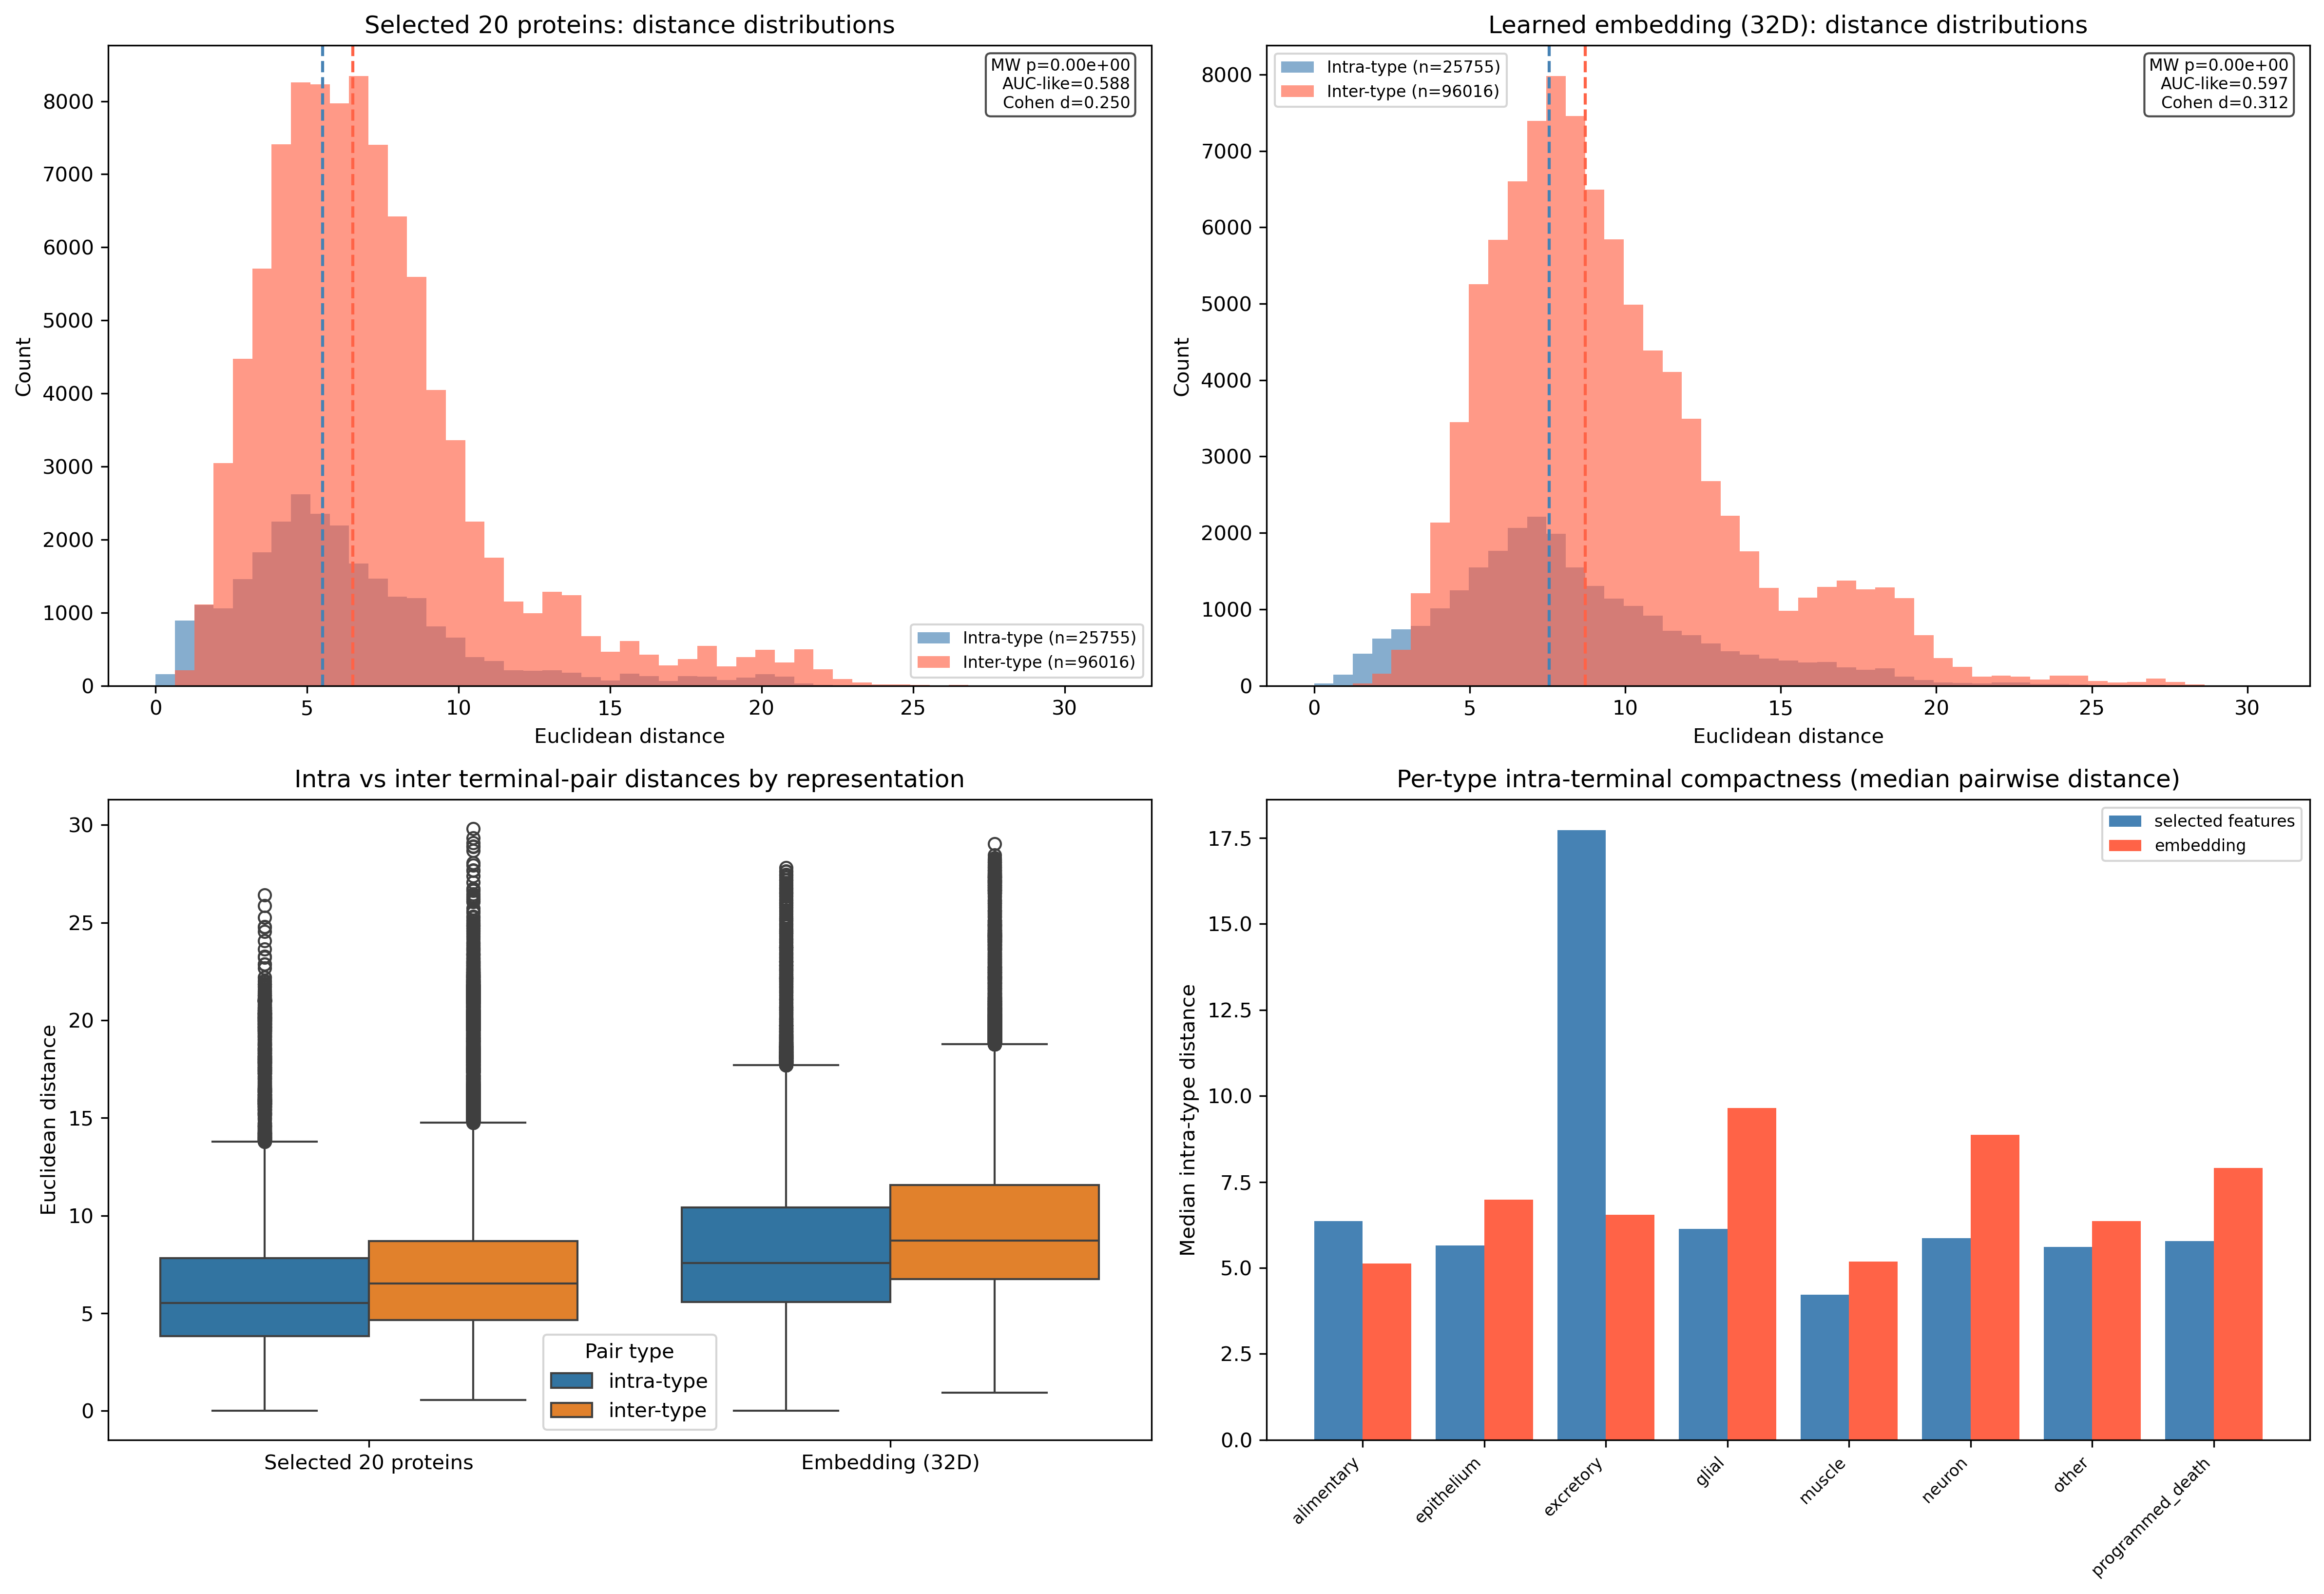

Interpretation guide: lower intra/inter overlap, higher median-ratio, larger Cohen d,
and higher AUC-like all indicate stronger type separation in that space.


In [26]:
# ─── Global terminal-pair distance comparison: intra-type vs inter-type ─────────
from itertools import combinations
from scipy.stats import mannwhitneyu, ks_2samp
from scipy.spatial.distance import pdist

# Terminal-only representations
term_idx = np.where(terminal_mask)[0]
term_types = y.argmax(axis=1)[term_idx]
term_type_names = np.array([cell_types[t] for t in term_types])

term_feat = X_sel[term_idx]
term_emb = embeddings[term_idx]

# Condensed pairwise distances for all i<j terminal pairs
feat_condensed = pdist(term_feat, metric='euclidean')
emb_condensed  = pdist(term_emb,  metric='euclidean')

# Build same-type mask in condensed-order
n_term = len(term_idx)
n_pairs = n_term * (n_term - 1) // 2
same_type_mask = np.fromiter(
    (term_types[i] == term_types[j] for i, j in combinations(range(n_term), 2)),
    dtype=bool,
    count=n_pairs,
 )
diff_type_mask = ~same_type_mask

feat_same = feat_condensed[same_type_mask]
feat_diff = feat_condensed[diff_type_mask]
emb_same  = emb_condensed[same_type_mask]
emb_diff  = emb_condensed[diff_type_mask]

def summarize_separation(same_d, diff_d, alternative='less'):
    u_stat, p_mw = mannwhitneyu(same_d, diff_d, alternative=alternative)
    ks_stat, p_ks = ks_2samp(same_d, diff_d)

    n1, n2 = len(same_d), len(diff_d)
    sd1 = np.std(same_d, ddof=1) if n1 > 1 else np.nan
    sd2 = np.std(diff_d, ddof=1) if n2 > 1 else np.nan
    pooled_std = np.sqrt(((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2) / (n1 + n2 - 2)) if (n1 + n2) > 2 else np.nan
    cohen_d = (np.mean(diff_d) - np.mean(same_d)) / pooled_std if pooled_std and not np.isnan(pooled_std) else np.nan

    auc_like = 1.0 - (u_stat / (n1 * n2))
    return {
        'n_same_pairs': n1,
        'n_diff_pairs': n2,
        'same_mean': float(np.mean(same_d)),
        'same_median': float(np.median(same_d)),
        'same_std': float(np.std(same_d, ddof=1)),
        'diff_mean': float(np.mean(diff_d)),
        'diff_median': float(np.median(diff_d)),
        'diff_std': float(np.std(diff_d, ddof=1)),
        'median_ratio_diff_over_same': float(np.median(diff_d) / np.median(same_d)),
        'cohen_d': float(cohen_d),
        'auc_like': float(auc_like),
        'mw_u': float(u_stat),
        'mw_pvalue_same_less_diff': float(p_mw),
        'ks_d': float(ks_stat),
        'ks_pvalue': float(p_ks),
    }

feat_stats = summarize_separation(feat_same, feat_diff)
emb_stats  = summarize_separation(emb_same, emb_diff)

summary_df = pd.DataFrame([
    {'space': f'Selected {X_sel.shape[1]} proteins', **feat_stats},
    {'space': f'Learned embedding ({embeddings.shape[1]}D)', **emb_stats},
])

print(f"Terminal cells: {n_term} | total terminal pairs: {n_pairs}")
print(f"Intra-type pairs: {same_type_mask.sum()} | Inter-type pairs: {diff_type_mask.sum()}\n")
display(summary_df.round(4))

# ── Visualizations ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Hist: selected features
ax = axes[0, 0]
bins_feat = np.linspace(0, max(feat_same.max(), feat_diff.max()) * 1.05, 50)
ax.hist(feat_same, bins=bins_feat, alpha=0.65, color='steelblue', label=f'Intra-type (n={len(feat_same)})')
ax.hist(feat_diff, bins=bins_feat, alpha=0.65, color='tomato', label=f'Inter-type (n={len(feat_diff)})')
ax.axvline(np.median(feat_same), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(np.median(feat_diff), color='tomato', linestyle='--', linewidth=1.5)
ax.set_title(f'Selected {X_sel.shape[1]} proteins: distance distributions')
ax.set_xlabel('Euclidean distance')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.text(
    0.98, 0.98,
    f"MW p={feat_stats['mw_pvalue_same_less_diff']:.2e}\nAUC-like={feat_stats['auc_like']:.3f}\nCohen d={feat_stats['cohen_d']:.3f}",
    transform=ax.transAxes, ha='right', va='top', fontsize=8,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
)

# Hist: embedding
ax = axes[0, 1]
bins_emb = np.linspace(0, max(emb_same.max(), emb_diff.max()) * 1.05, 50)
ax.hist(emb_same, bins=bins_emb, alpha=0.65, color='steelblue', label=f'Intra-type (n={len(emb_same)})')
ax.hist(emb_diff, bins=bins_emb, alpha=0.65, color='tomato', label=f'Inter-type (n={len(emb_diff)})')
ax.axvline(np.median(emb_same), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(np.median(emb_diff), color='tomato', linestyle='--', linewidth=1.5)
ax.set_title(f'Learned embedding ({embeddings.shape[1]}D): distance distributions')
ax.set_xlabel('Euclidean distance')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.text(
    0.98, 0.98,
    f"MW p={emb_stats['mw_pvalue_same_less_diff']:.2e}\nAUC-like={emb_stats['auc_like']:.3f}\nCohen d={emb_stats['cohen_d']:.3f}",
    transform=ax.transAxes, ha='right', va='top', fontsize=8,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
)

# Boxplot comparison across spaces
ax = axes[1, 0]
long_df = pd.DataFrame({
    'distance': np.concatenate([feat_same, feat_diff, emb_same, emb_diff]),
    'pair_type': (['intra-type'] * len(feat_same) + ['inter-type'] * len(feat_diff) +
                  ['intra-type'] * len(emb_same)  + ['inter-type'] * len(emb_diff)),
    'space': ([f'Selected {X_sel.shape[1]} proteins'] * (len(feat_same) + len(feat_diff)) +
              [f'Embedding ({embeddings.shape[1]}D)'] * (len(emb_same) + len(emb_diff))),
})
sns.boxplot(data=long_df, x='space', y='distance', hue='pair_type', ax=ax)
ax.set_title('Intra vs inter terminal-pair distances by representation')
ax.set_xlabel('')
ax.set_ylabel('Euclidean distance')
ax.legend(title='Pair type')

# Type-level medians (intra only) as a sanity view
ax = axes[1, 1]
intra_feat_by_type = defaultdict(list)
intra_emb_by_type  = defaultdict(list)

for i in range(n_term):
    for j in range(i + 1, n_term):
        if term_types[i] == term_types[j]:
            tname = term_type_names[i]
            d_f = np.linalg.norm(term_feat[i] - term_feat[j])
            d_e = np.linalg.norm(term_emb[i] - term_emb[j])
            intra_feat_by_type[tname].append(d_f)
            intra_emb_by_type[tname].append(d_e)

common_types = sorted([t for t in intra_feat_by_type.keys() if len(intra_feat_by_type[t]) >= 3])
if len(common_types) > 0:
    feat_medians = [np.median(intra_feat_by_type[t]) for t in common_types]
    emb_medians  = [np.median(intra_emb_by_type[t])  for t in common_types]
    x = np.arange(len(common_types))
    w = 0.4
    ax.bar(x - w/2, feat_medians, width=w, color='steelblue', label='selected features')
    ax.bar(x + w/2, emb_medians,  width=w, color='tomato', label='embedding')
    ax.set_xticks(x)
    ax.set_xticklabels(common_types, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Median intra-type distance')
    ax.set_title('Per-type intra-terminal compactness (median pairwise distance)')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'Not enough intra-type pairs per type for per-type plot', ha='center', va='center')
    ax.set_axis_off()

plt.tight_layout()
plt.show()

print('Interpretation guide: lower intra/inter overlap, higher median-ratio, larger Cohen d,')
print('and higher AUC-like all indicate stronger type separation in that space.')

In [27]:
top_features     = feature_names[top_idx]
trimmed_proteins = [f.rsplit('_', 1)[0] for f in top_features]
trimmed_proteins

['HLH-2',
 'CEH-45',
 'CEH-27',
 'CEH-43',
 'LIM-6',
 'NHR-25',
 'EGRH-1',
 'SOX-2',
 'HAM-2',
 'ZAG-1',
 'PHA-4',
 'MEP-1',
 'PAX-1',
 'COG-1',
 'ELT-6',
 'CEH-36',
 'CEH-34',
 'POP-1',
 'HLH-3',
 'CRH-2']

In [28]:
embed_dim = embeddings.shape[1]
emb_cols = [f"emb_{i}" for i in range(embed_dim)]
emb_df = pd.DataFrame(embeddings, index=cell_names, columns=emb_cols)
emb_df.index.name = 'cell_name'

emb_df.to_csv(FEATURE_EMBEDDINGS_PATH)
pd.Series(trimmed_proteins).to_csv(
    FEATURE_SELECTED_PROTEINS_PATH,
    sep='\t',
    index=False,
    header=False,
 )

print(f"Saved embeddings ({embed_dim}D) -> {FEATURE_EMBEDDINGS_PATH}")
print(f"Saved selected proteins        -> {FEATURE_SELECTED_PROTEINS_PATH}")
print(f"Selected proteins: {trimmed_proteins}")

Saved embeddings (32D) -> /home/bingran/code/embryogenesis/expression_embedding/results/elegans_protein_schemaD_no_dead_embedding/embeddings_32d.csv
Saved selected proteins        -> /home/bingran/code/embryogenesis/expression_embedding/results/elegans_protein_schemaD_no_dead_embedding/nn_selected_proteins_rev.tsv
Selected proteins: ['HLH-2', 'CEH-45', 'CEH-27', 'CEH-43', 'LIM-6', 'NHR-25', 'EGRH-1', 'SOX-2', 'HAM-2', 'ZAG-1', 'PHA-4', 'MEP-1', 'PAX-1', 'COG-1', 'ELT-6', 'CEH-36', 'CEH-34', 'POP-1', 'HLH-3', 'CRH-2']


In [29]:
tissue_specific_tfs = pd.read_csv(TISSUE_SPECIFIC_TF_PATH, sep='\t', header=None, index_col=0).index.tolist()
tissue_specific_selected_proteins = list(set(tissue_specific_tfs).intersection(set(trimmed_proteins)))

In [30]:
# a new X_tissue_specific from the tissue_specific_selected_proteins
tissue_specific_indices = [i for i, f in enumerate(feature_names) if f.rsplit('_', 1)[0] in tissue_specific_selected_proteins]
X_tissue_specific = X[:, tissue_specific_indices]